In [ ]:

# ================================================================
# CELL 0: DATA EXPLORATION - VITON-HD + DLP Dataset
# Copy toàn bộ cell này vào Kaggle notebook và chạy
# Gửi lại toàn bộ output text cho tôi
# ================================================================

import os, json, random
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from collections import defaultdict

# ── PATHS ────────────────────────────────────────────────────────
VITON_ROOT   = Path("/kaggle/input/datasets/marquis03/high-resolution-viton-zalando-dataset")
CSV_ROOT     = Path("/kaggle/input/datasets/cthnhoddt/dlp-cleandatacsv")
CAPTION_ROOT = Path("/kaggle/input/datasets/cthnhoddt/dlp-cloth-caption")

TRAIN_DIR = VITON_ROOT / "train"
TEST_DIR  = VITON_ROOT / "test"

# ════════════════════════════════════════════════════════════════
# 1. CẤU TRÚC THƯ MỤC
# ════════════════════════════════════════════════════════════════
print("=" * 65)
print("VITON-HD: TOP LEVEL")
print("=" * 65)
for p in sorted(VITON_ROOT.iterdir()):
    print(f"  {'[DIR] ' if p.is_dir() else '[FILE]'} {p.name}")

print("\n" + "=" * 65)
print("VITON-HD / train  (tên folder chính xác + số file + extensions)")
print("=" * 65)
for sub in sorted(TRAIN_DIR.iterdir()):
    if sub.is_dir():
        files = list(sub.iterdir())
        exts  = set(f.suffix.lower() for f in files)
        print(f"  {sub.name:40s} | {len(files):6d} files | {exts}")
    else:
        print(f"  [FILE] {sub.name}")

print("\n" + "=" * 65)
print("VITON-HD / test  (tên folder + số file)")
print("=" * 65)
for sub in sorted(TEST_DIR.iterdir()):
    if sub.is_dir():
        files = list(sub.iterdir())
        exts  = set(f.suffix.lower() for f in files)
        print(f"  {sub.name:40s} | {len(files):6d} files | {exts}")
    else:
        print(f"  [FILE] {sub.name}")

# ════════════════════════════════════════════════════════════════
# 2. DLP DATA (CSV + CAPTION)
# ════════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("DLP CSV ROOT")
print("=" * 65)
for p in sorted(CSV_ROOT.iterdir()):
    print(f"  {p.name}  ({p.stat().st_size:,} bytes)")

print("\n" + "=" * 65)
print("DLP CAPTION ROOT")
print("=" * 65)
for p in sorted(CAPTION_ROOT.iterdir()):
    if p.is_dir():
        subs = list(p.iterdir())
        print(f"  [DIR] {p.name} ({len(subs)} children)")
        for s in sorted(subs):
            if s.is_dir():
                n = len(list(s.iterdir()))
                print(f"         [DIR] {s.name} ({n} files)")
            else:
                print(f"         [FILE] {s.name}")
    else:
        print(f"  [FILE] {p.name}")

# ════════════════════════════════════════════════════════════════
# 3. NỘI DUNG CSV
# ════════════════════════════════════════════════════════════════
import pandas as pd

print("\n" + "=" * 65)
print("CSV: clean_vto_dataset_train.csv")
print("=" * 65)
df_train = pd.read_csv(CSV_ROOT / "clean_vto_dataset_train.csv")
print(f"  Shape: {df_train.shape}")
print(f"  Columns: {list(df_train.columns)}")
print("  First 3 rows:")
print(df_train.head(3).to_string())

print("\n" + "=" * 65)
print("CSV: clean_vto_dataset_test.csv")
print("=" * 65)
df_test = pd.read_csv(CSV_ROOT / "clean_vto_dataset_test.csv")
print(f"  Shape: {df_test.shape}")
print(f"  Columns: {list(df_test.columns)}")
print("  First 3 rows:")
print(df_test.head(3).to_string())

print("\n" + "=" * 65)
print("CSV: holdout_test.csv")
print("=" * 65)
df_hold = pd.read_csv(CSV_ROOT / "holdout_test.csv")
print(f"  Shape: {df_hold.shape}")
print(f"  Columns: {list(df_hold.columns)}")
print("  First 3 rows:")
print(df_hold.head(3).to_string())

# Caption sample
print("\n" + "=" * 65)
print("CAPTION SAMPLES (train)")
print("=" * 65)
cap_train = list((CAPTION_ROOT / "cloth-captions" / "train").iterdir())[:5] \
    if (CAPTION_ROOT / "cloth-captions" / "train").exists() else []
for f in cap_train:
    print(f"  {f.name}: {f.read_text().strip()}")

# ════════════════════════════════════════════════════════════════
# 4. ĐỌC TỪNG LOẠI FILE — SHAPE + FORMAT
# ════════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("SAMPLE FILE INFO PER FOLDER (1 file mỗi folder)")
print("=" * 65)

# Lấy 1 person_id và cloth_id từ train CSV
pid = str(df_train.iloc[0]["id"]) if "id" in df_train.columns else str(df_train.iloc[0].iloc[0])
print(f"  Using person_id = '{pid}' to probe all folders\n")

folders_probe = [
    ("image",                  pid, [".jpg", ".png"]),
    ("cloth",                  pid, [".jpg", ".png"]),
    ("cloth-mask",             pid, [".jpg", ".png"]),
    ("agnostic-v3.2",          pid, [".jpg", ".png"]),
    ("image-parse-v3",         pid, [".png", ".jpg"]),
    ("image-densepose",        pid, [".jpg", ".png"]),
    ("openpose_img",           pid, [".jpg", ".png"]),
    ("openpose_json",          pid, [".json"]),
]

# Thêm tất cả folder còn lại mà chưa list
known = {x[0] for x in folders_probe}
for sub in sorted(TRAIN_DIR.iterdir()):
    if sub.is_dir() and sub.name not in known:
        folders_probe.append((sub.name, pid, [".png", ".jpg", ".json"]))

for folder, stem, exts in folders_probe:
    folder_path = TRAIN_DIR / folder
    if not folder_path.exists():
        print(f"  {folder:40s} -> MISSING")
        continue
    found = None
    for ext in exts:
        fp = folder_path / f"{stem}{ext}"
        if fp.exists():
            found = fp; break
    # fallback: first file in folder
    if not found:
        all_files = list(folder_path.iterdir())
        if all_files:
            found = all_files[0]
            print(f"  {folder:40s} -> pid not found, using: {found.name}")
        else:
            print(f"  {folder:40s} -> EMPTY"); continue
    try:
        if found.suffix.lower() == ".json":
            with open(found) as f: data = json.load(f)
            print(f"  {folder:40s} -> JSON top-keys: {list(data.keys())}")
            if "people" in data and data["people"]:
                p0 = data["people"][0]
                print(f"    people[0] keys: {list(p0.keys())}")
                for k, v in p0.items():
                    print(f"      {k}: length={len(v)}, first_6={v[:6]}")
        else:
            img = Image.open(found)
            arr = np.array(img)
            info = f"size={img.size} mode={img.mode} dtype={arr.dtype} range=[{arr.min()},{arr.max()}]"
            print(f"  {folder:40s} -> {info}")
            if "parse" in folder:
                ulabels = np.unique(arr).tolist()
                print(f"    unique labels: {ulabels}")
    except Exception as e:
        print(f"  {folder:40s} -> ERROR: {e}")

# ════════════════════════════════════════════════════════════════
# 5. CROSS-CHECK: CSV ids vs actual files
# ════════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("CROSS-CHECK: 10 train ids -> files exist in image/ folder?")
print("=" * 65)
img_dir = TRAIN_DIR / "image"
for _, row in df_train.head(10).iterrows():
    rid = str(row["id"]) if "id" in df_train.columns else str(row.iloc[0])
    found_jpg = (img_dir / f"{rid}.jpg").exists()
    found_png = (img_dir / f"{rid}.png").exists()
    print(f"  {rid}: jpg={found_jpg} png={found_png}")

# ════════════════════════════════════════════════════════════════
# 6. VISUALIZE 2 SAMPLE
# ════════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("VISUALIZING 2 SAMPLES")
print("=" * 65)

sample_ids = df_train["id"].astype(str).tolist()[:2] if "id" in df_train.columns else []

for idx, pid in enumerate(sample_ids):
    to_show = []
    for folder in ["image", "cloth", "cloth-mask", "agnostic-v3.2",
                   "image-parse-v3", "image-densepose", "openpose_img"]:
        fp = None
        for ext in [".jpg", ".png"]:
            p = TRAIN_DIR / folder / f"{pid}{ext}"
            if p.exists(): fp = p; break
        to_show.append((folder.split("/")[-1], fp))

    cols = len(to_show)
    fig, axes = plt.subplots(1, cols, figsize=(cols * 3, 4))
    fig.suptitle(f"Sample {idx+1}: {pid}", fontsize=11)
    for ax, (title, fp) in zip(axes, to_show):
        if fp and fp.exists():
            img = Image.open(fp).convert("RGB")
            ax.imshow(img)
            ax.set_title(f"{title}\n{img.size}", fontsize=7)
        else:
            ax.set_title(f"{title}\nMISSING", fontsize=7, color="red")
        ax.axis("off")
    plt.tight_layout()
    plt.savefig(f"/kaggle/working/explore_sample_{idx+1}.png", dpi=80, bbox_inches="tight")
    plt.show()

print("\n=== EXPLORATION DONE ===")
print("Copy toàn bộ output TEXT này gửi lại cho tôi!")


In [ ]:

# ================================================================
# CELL 1: CÀI ĐẶT THƯ VIỆN
# ⚠️ SAU KHI CHẠY XONG CELL NÀY → BẮT BUỘC RESTART KERNEL
#    (Menu: Run > Restart Session, rồi bỏ qua Cell này và chạy từ Cell 2)
# ================================================================
import subprocess, sys

def pip(cmd):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "--no-input", "--no-cache-dir"] + cmd.split())

def run(cmd):
    subprocess.call(cmd)

# 0. Gỡ các wheel numpy/scipy lỗi nếu Kaggle kernel đã bị kéo lệch package.
run([sys.executable, "-m", "pip", "uninstall", "-y", "-q", "numpy", "scipy"])

# 1. Pin numpy/scipy trước để tránh cascade upgrade phá vỡ diffusers/skimage.
# scipy 1.13.1 hỗ trợ Python 3.12; scipy 1.11.x không ổn trên Kaggle py3.12.
pip("--upgrade --force-reinstall numpy==1.26.4 scipy==1.13.1")

# 2. Core ML stack (đã test tương thích với nhau)
pip("diffusers==0.30.3")
pip("transformers==4.44.2")
pip("peft==0.12.0")
pip("accelerate==0.34.2")   # >=0.34 hỗ trợ numpy 1.26
pip("xformers")

# 3. Experiment tracking + Metrics
pip("wandb")
pip("lpips")

# 4. Image processing
pip("opencv-python-headless==4.9.0.80")  # pin để tránh xung đột numpy>=2
pip("scikit-image==0.24.0")

# 5. Repair cuối cùng: một số package, đặc biệt xformers, có thể kéo lại numpy.
# Pin lại lần cuối rồi restart kernel trước khi chạy Cell 2.
pip("--upgrade --force-reinstall numpy==1.26.4 scipy==1.13.1")

print("=" * 50)
print("✅ Cài đặt xong!")
print()
print("⚠️  QUAN TRỌNG: Bây giờ phải RESTART KERNEL!")
print("   Menu: Run → Restart Session")
print("   (Sau restart: bỏ qua Cell 1, chạy thẳng từ Cell 2)")
print("   Không kiểm tra numpy trong chính Cell 1 vì kernel cũ có thể giữ module lỗi trong memory.")
print("=" * 50)


In [3]:



import os, random, json, math, gc, shutil, warnings, zipfile
from pathlib import Path
from dataclasses import dataclass, field
from typing import List, Optional

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset, DataLoader
from torch.optim.swa_utils import AveragedModel, get_ema_multi_avg_fn

from diffusers import AutoencoderKL, UNet2DConditionModel, DDPMScheduler, DDIMScheduler
from transformers import (
    CLIPTokenizer, CLIPImageProcessor,
    CLIPTextModel, CLIPVisionModelWithProjection,
    get_cosine_schedule_with_warmup
)
from peft import LoraConfig, get_peft_model, set_peft_model_state_dict
from safetensors.torch import load_file as load_safetensors
from accelerate import Accelerator
from accelerate.utils import set_seed

import wandb
import lpips
from skimage.metrics import structural_similarity as ssim_metric
from skimage.metrics import peak_signal_noise_ratio as psnr_metric

warnings.filterwarnings("ignore")


VITON_ROOT   = Path("/kaggle/input/datasets/marquis03/high-resolution-viton-zalando-dataset")
CSV_ROOT     = Path("/kaggle/input/datasets/cthnhoddt/dlp-cleandatacsv")
CAPTION_ROOT = Path("/kaggle/input/datasets/cthnhoddt/dlp-cloth-caption")

TRAIN_DIR = VITON_ROOT / "train"
TEST_DIR  = VITON_ROOT / "test"

OUTPUT_DIR = Path("/kaggle/working/vto_v2")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


RESUME_EPOCH = 4


def restore_resume_checkpoint_from_input(epoch):
    ckpt_dst = OUTPUT_DIR / "checkpoint_latest"
    hist_dst = OUTPUT_DIR / "loss_history.json"
    if epoch is None:
        return

    if (ckpt_dst / "conv_in.pt").exists() and hist_dst.exists():
        try:
            with open(hist_dst, encoding="utf-8") as f:
                existing_hist = json.load(f)
            if int(existing_hist.get("epochs_done", -1)) == int(epoch):
                print(f"Checkpoint epoch {epoch} đã có sẵn tại: {ckpt_dst}")
                return
        except Exception:
            pass

    if ckpt_dst.exists():
        shutil.rmtree(ckpt_dst)
    if hist_dst.exists():
        hist_dst.unlink()

    ep = int(epoch)
    ep2 = f"{ep:02d}"
    candidates = [
        Path(f"/kaggle/input/datasets/hypivepiu/ckpt-epoch-{ep2}"),
        Path(f"/kaggle/input/datasets/hypivepiu/ckpt-epoch-{ep2}/checkpoint_latest"),
        Path(f"/kaggle/input/datasets/hypivepiu/ckpt-epoch-{ep2}/checkpoint_epoch_{ep2}.zip"),
        Path(f"/kaggle/input/datasets/hypivepiu/ckpt-epoch-{ep}"),
        Path(f"/kaggle/input/datasets/hypivepiu/ckpt-epoch-{ep}/checkpoint_latest"),
        Path(f"/kaggle/input/datasets/hypivepiu/ckpt-epoch-{ep}/checkpoint_epoch_{ep2}.zip"),
        Path(f"/kaggle/input/datasets/khoaanh1234/ckpt-epo-{ep2}"),
        Path(f"/kaggle/input/datasets/khoaanh1234/ckpt-epo-{ep}"),
        Path(f"/kaggle/input/ckpt-epo-{ep2}"),
        Path(f"/kaggle/input/ckpt-epo-{ep}"),
    ]

    required_files = [
        "conv_in.pt",
        "perceiver.pt",
        "cloth_spatial.pt",
        "unet_lora/adapter_config.json",
        "unet_lora/adapter_model.safetensors",
    ]

    def has_resume_structure(ckpt):
        return all((ckpt / rel).exists() for rel in required_files)

    def valid_resume_source(path):
        if not path.exists():
            return False
        if path.is_file():
            return path.suffix == ".zip"
        if path.name == "checkpoint_latest":
            return has_resume_structure(path)
        return has_resume_structure(path / "checkpoint_latest")

    source = next((p for p in candidates if valid_resume_source(p)), None)
    if source is None:
        checked = "\n".join(f"  - {p}" for p in candidates)
        raise FileNotFoundError(
            f"Không tìm thấy checkpoint epoch {ep}. Các đường dẫn đã kiểm tra:\n{checked}"
        )

    print(f" Khôi phục checkpoint epoch {ep} từ: {source}")
    if source.is_file() and source.suffix == ".zip":
        with zipfile.ZipFile(source, "r") as zf:
            zf.extractall(OUTPUT_DIR)
    else:
        src_ckpt = source if source.name == "checkpoint_latest" else source / "checkpoint_latest"
        if not src_ckpt.exists():
            print(f"  Nguồn resume không có checkpoint_latest: {source}")
            return
        shutil.copytree(src_ckpt, ckpt_dst)
        for hist_src in [source / "loss_history.json", source.parent / "loss_history.json"]:
            if hist_src.exists():
                shutil.copy2(hist_src, hist_dst)
                break

    if has_resume_structure(ckpt_dst) and hist_dst.exists():
        print(f" Đã chuẩn bị resume checkpoint tại: {ckpt_dst}")
    else:
        raise RuntimeError(
            "Checkpoint restore thiếu weight hoặc loss_history.json cần thiết. "
            "Không tiếp tục để tránh vô tình train lại từ đầu."
        )


restore_resume_checkpoint_from_input(RESUME_EPOCH)


@dataclass
class Config:

    model_id: str      = "runwayml/stable-diffusion-inpainting"
    ip_adapter_id: str = "h94/IP-Adapter"


    target_h: int  = 512
    target_w: int  = 384
    trigger_word: str = "hyeiu_cloth"
    max_train_samples: Optional[int] = None
    num_workers: int = 2


    seed: int         = 42
    batch_size: int   = 1
    grad_accum: int   = 8
    num_epochs: int   = 20
    lr: float         = 2e-5
    conv_in_lr: float = 1e-4
    weight_decay: float = 1e-4
    warmup_steps: int = 200
    early_stop_patience: int = 5


    lora_rank: int    = 16
    lora_alpha: int   = 16
    lora_dropout: float = 0.05
    lora_targets: List[str] = field(default_factory=lambda: [
        "to_q", "to_k", "to_v", "to_out.0", "ff.net.0.proj", "ff.net.2"
    ])


    num_image_tokens: int   = 8
    num_spatial_tokens: int = 64
    perceiver_depth: int    = 2
    perceiver_heads: int    = 8
    unet_in_channels: int   = 17


    mask_loss_weight: float = 6.0
    x0_latent_loss_weight: float = 0.40
    x0_mask_loss_weight: float = 6.0
    min_snr_gamma: float    = 5.0
    cfg_drop_text: float    = 0.05
    cfg_drop_cloth: float   = 0.05


    ema_decay: float = 0.999


    num_inference_steps: int = 45
    guidance_scale: float    = 2.0
    guidance_sweep: List[float] = field(default_factory=lambda: [1.5, 2.0, 2.5, 3.0])
    infer_csv_name: str = "holdout_test.csv"


    vae_scale: float = 0.18215


    wandb_project: str = "VTO-Model4-SD-LoRA"
    wandb_run_name: str = "v2-perceiver-13ch"
    use_wandb: bool    = True

cfg = Config()

def seed_everything(s: int):
    random.seed(s)
    np.random.seed(s)
    torch.manual_seed(s)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(s)
    os.environ["PYTHONHASHSEED"] = str(s)

seed_everything(cfg.seed)


if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

print(f" Config loaded")
print(f"   Target size    : {cfg.target_w}×{cfg.target_h} (W×H)")
print(f"   LoRA rank      : {cfg.lora_rank}")
print(f"   UNet channels  : {cfg.unet_in_channels}")
print(f"   Effective batch: {cfg.batch_size * cfg.grad_accum}")
print(f"   CUDA available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"   GPU {i}: {torch.cuda.get_device_name(i)} ({torch.cuda.get_device_properties(i).total_memory // 1024**3}GB)")


 Khôi phục checkpoint epoch 4 từ: /kaggle/input/datasets/hypivepiu/ckpt-epoch-04
 Đã chuẩn bị resume checkpoint tại: /kaggle/working/vto_v2/checkpoint_latest
 Config loaded
   Target size    : 384×512 (W×H)
   LoRA rank      : 16
   UNet channels  : 17
   Effective batch: 8
   CUDA available : True
   GPU 0: Tesla T4 (14GB)
   GPU 1: Tesla T4 (14GB)


Khởi tạo train dataset...


tokenizer_config.json:   0%|          | 0.00/806 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

✅ VTODatasetV2 [train]: 9520 pairs | augment=True
✅ VTODatasetV2 [test]: 996 pairs | augment=False

📊 Dataset sizes:
   Train : 9,520 samples
   Test  : 996 samples

🔍 Train sample[0]
   image          : (3, 512, 384)  dtype=torch.float32  range=[-0.94, 1.00]
   agnostic       : (3, 512, 384)  dtype=torch.float32  range=[-0.95, 0.96]
   pose           : (3, 512, 384)  dtype=torch.float32  range=[-1.00, 1.00]
   cloth          : (3, 512, 384)  dtype=torch.float32  range=[-0.70, 1.00]
   inpaint_mask   : (1, 512, 384)  dtype=torch.float32  range=[0.00, 1.00]
   clip_cloth     : (3, 224, 224)  dtype=torch.float32  range=[-1.15, 2.15]
   input_ids      : (77,)  dtype=torch.int64  range=[261.00, 49407.00]
   caption        : 'hyeiu_cloth, a professional studio photo of levi & levi levi logo t - shirt whit'
   person_id      : '00000_00'
   cloth_id       : '00000_00'


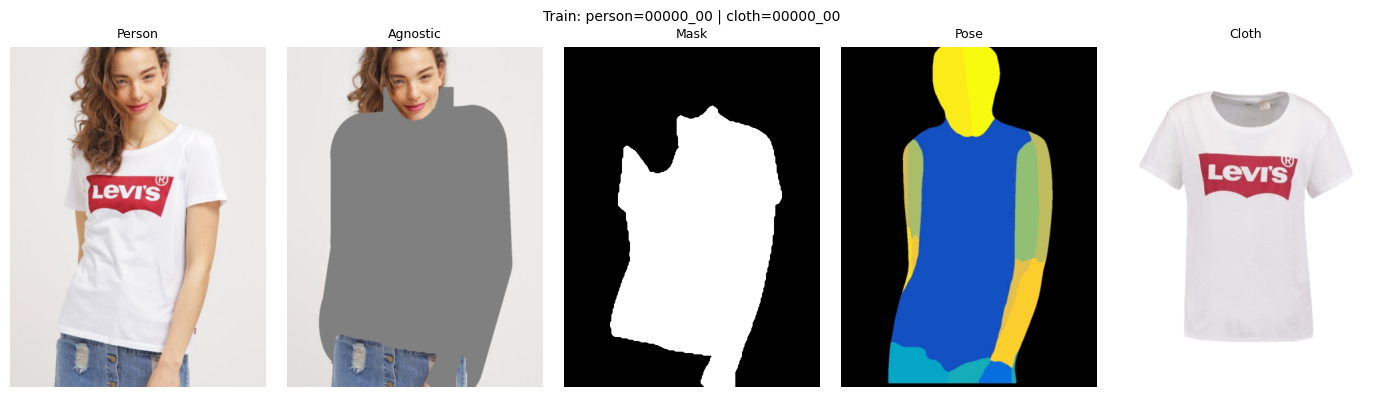


🔍 Test / Validation sample[0]
   image          : (3, 512, 384)  dtype=torch.float32  range=[-1.00, 1.00]
   agnostic       : (3, 512, 384)  dtype=torch.float32  range=[-1.00, 0.98]
   pose           : (3, 512, 384)  dtype=torch.float32  range=[-1.00, 1.00]
   cloth          : (3, 512, 384)  dtype=torch.float32  range=[-1.00, 1.00]
   inpaint_mask   : (1, 512, 384)  dtype=torch.float32  range=[0.00, 1.00]
   clip_cloth     : (3, 224, 224)  dtype=torch.float32  range=[-1.75, 2.15]
   input_ids      : (77,)  dtype=torch.int64  range=[267.00, 49407.00]
   caption        : 'hyeiu_cloth, a professional studio photo of a top - topper'
   person_id      : '10177_00'
   cloth_id       : '10177_00'


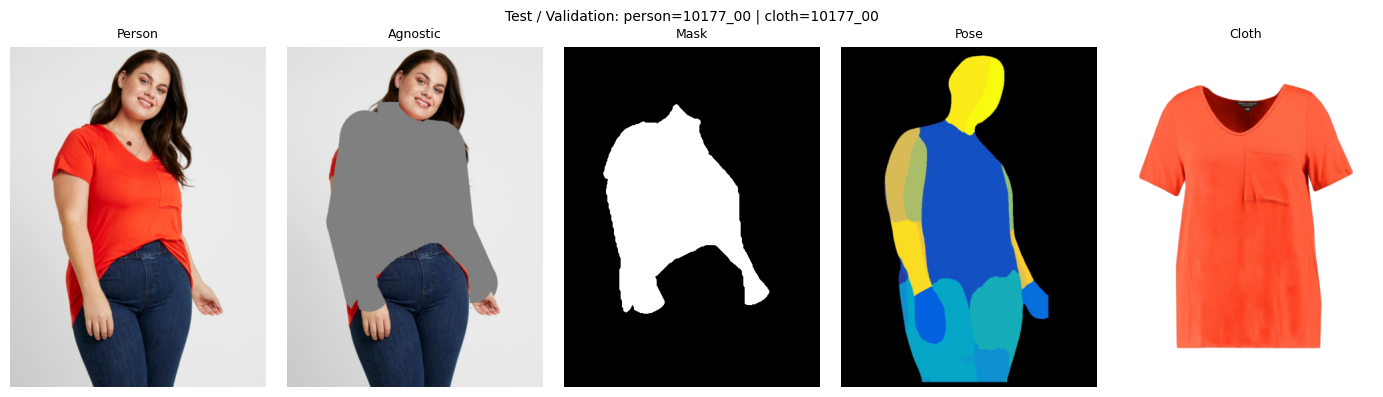

In [4]:

# ================================================================
# CELL 3: DATASET CLASS - VTODatasetV2
# Khai thác toàn bộ 9 loại data VITON-HD
# ================================================================

class VTODatasetV2(Dataset):
    """
    Dataset cho SD Inpainting + IP-Adapter + LoRA (V2).

    Inputs per sample (7 loại data VITON-HD):
    ┌─────────────────────────┬──────────────────────────────────────────┐
    │ Tên tensor              │ Mô tả                                    │
    ├─────────────────────────┼──────────────────────────────────────────┤
    │ image          (3,H,W)  │ Ảnh người mặc áo (Ground Truth)          │
    │ agnostic       (3,H,W)  │ Ảnh người sau khi xóa áo (nền)           │
    │ inpaint_mask   (1,H,W)  │ Mask vùng cần vẽ lại (từ parse diff)     │
    │ pose           (3,H,W)  │ DensePose / OpenPose rendered             │
    │ cloth          (3,H,W)  │ Ảnh áo (đã cắt nền trắng)               │
    │ clip_cloth  (3,224,224) │ Ảnh áo resize 224px cho CLIP            │
    │ input_ids      (77,)    │ Token caption áo                         │
    └─────────────────────────┴──────────────────────────────────────────┘

    Train/Val Strategy:
      - train_ds: paired reconstruction, person_id == cloth_id, có GT để backward.
      - test_ds : paired reconstruction từ clean test person_id, có GT để tính val loss.
      - unpaired/cross-pairing chỉ dùng ở Cell 8 để nhìn ảnh qualitative, không backward.

    Mask Strategy:
      Diff giữa image-parse-v3 và image-parse-agnostic-v3.2:
      Pixel nào xuất hiện trong parse-v3 nhưng KHÔNG có trong parse-agnostic
      = pixel bị xóa khi làm agnostic = vùng áo cần inpaint.
      Robust hơn hardcode label number vì VITON-HD ở dataset này dùng label áo là 5
      trên nhiều mẫu, không phải {4, 7} như một số tài liệu LIP/CIHP khác.
    """

    def __init__(self, cfg, split="train", augment=False):
        self.cfg     = cfg
        self.split   = split
        self.augment = augment
        self.root    = TRAIN_DIR if split == "train" else TEST_DIR
        self.h, self.w = cfg.target_h, cfg.target_w
        self.ratio   = self.w / self.h

        # Load CSV
        if split == "train":
            df_raw = pd.read_csv(CSV_ROOT / "clean_vto_dataset_train.csv")
            # Supervised training: paired only, vì unpaired không có GT để backward.
            # Train CSV clean chỉ có 'id' nên person_id = cloth_id.
            self.pairs = [(str(row["id"]), str(row["id"])) for _, row in df_raw.iterrows()]
            if cfg.max_train_samples:
                self.pairs = self.pairs[:cfg.max_train_samples]
        else:
            df_raw = pd.read_csv(CSV_ROOT / "clean_vto_dataset_test.csv")
            # Validation loss cũng phải paired để có GT đúng.
            # Cross-pair person_id-cloth_id của CSV chỉ dùng ở Cell 8 để preview unpaired.
            self.pairs = [(str(row["person_id"]), str(row["person_id"])) for _, row in df_raw.iterrows()]

        self.caption_dir = CAPTION_ROOT / "cloth-captions" / split

        # Tokenizer & CLIP processor
        self.tokenizer = CLIPTokenizer.from_pretrained(cfg.model_id, subfolder="tokenizer")
        self.clip_proc = CLIPImageProcessor.from_pretrained("openai/clip-vit-large-patch14")

        print(f"✅ VTODatasetV2 [{split}]: {len(self.pairs)} pairs | augment={augment}")

    def __len__(self):
        return len(self.pairs)

    # ── Helpers ──────────────────────────────────────────────────

    def _normalize(self, t):
        """[0,1] → [-1,1]"""
        return t * 2.0 - 1.0

    def _crop_resize(self, img, is_mask=False):
        """Center crop để đúng aspect ratio rồi resize."""
        w, h = img.size
        target_ratio = self.w / self.h
        if w / h > target_ratio:
            new_w = int(h * target_ratio)
            img = img.crop(((w - new_w) // 2, 0, (w - new_w) // 2 + new_w, h))
        else:
            new_h = int(w / target_ratio)
            img = img.crop((0, (h - new_h) // 2, w, (h - new_h) // 2 + new_h))
        interp = Image.NEAREST if is_mask else Image.BILINEAR
        return img.resize((self.w, self.h), interp)

    def _find_file(self, folder, stem, exts):
        """Tìm file với nhiều extension fallback."""
        for ext in exts:
            p = self.root / folder / f"{stem}{ext}"
            if p.exists():
                return p
        return None

    # ── Mask từ Parse Diff ────────────────────────────────────────

    def _compute_parse_mask(self, pid):
        """
        Inpainting mask bằng cách so sánh 2 parse map:
          - image-parse-v3        : parse của ảnh GỐC (có áo)
          - image-parse-agnostic-v3.2 : parse sau khi XÓA áo

        Pixel nào thay đổi label = vùng áo → mask=1
        Sau đó dilate nhẹ để đảm bảo phủ đủ viền áo.
        """
        parse_path    = self._find_file("image-parse-v3", pid, [".png"])
        agnostic_path = self._find_file("image-parse-agnostic-v3.2", pid, [".png"])

        if parse_path and agnostic_path:
            parse_np    = np.array(Image.open(parse_path))
            agnostic_np = np.array(Image.open(agnostic_path))

            # Resize về target resolution trước khi diff (tránh lỗi shape)
            h_orig, w_orig = parse_np.shape[:2]
            if (h_orig, w_orig) != (self.h, self.w):
                parse_np    = np.array(Image.fromarray(parse_np).resize((self.w, self.h), Image.NEAREST))
                agnostic_np = np.array(Image.fromarray(agnostic_np).resize((self.w, self.h), Image.NEAREST))

            # Vùng áo = pixel thay đổi label giữa parse gốc và parse agnostic.
            # Không dùng PARSE_UPPER_LABELS hardcode: output EDA cho thấy sample
            # áo thường là label 5, còn tài liệu cũ trong repo từng ghi {4,7}.
            cloth_mask = (parse_np != agnostic_np).astype(np.uint8) * 255

            # Close trước để lấp lỗ nhỏ trong vùng áo, rồi dilate để bọc kín viền.
            kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
            cloth_mask = cv2.morphologyEx(cloth_mask, cv2.MORPH_CLOSE, kernel, iterations=1)
            cloth_mask = cv2.dilate(cloth_mask, kernel, iterations=1)

            return Image.fromarray(cloth_mask, mode="L")
        else:
            # Fallback: mask toàn bộ vùng trên (top 60%)
            blank = np.zeros((self.h, self.w), dtype=np.uint8)
            blank[:int(self.h * 0.6), :] = 255
            return Image.fromarray(blank, mode="L")

    # ── Pose ─────────────────────────────────────────────────────

    def _load_pose(self, pid):
        """
        Ưu tiên DensePose (richer spatial info) > OpenPose rendered > gray fallback.
        DensePose cho thông tin bề mặt UV 3D của cơ thể người.
        """
        # 1. DensePose
        p = self._find_file("image-densepose", pid, [".jpg", ".png"])
        if p:
            return Image.open(p).convert("RGB")

        # 2. OpenPose rendered (filename có đuôi _rendered)
        p = self._find_file("openpose_img", f"{pid}_rendered", [".png", ".jpg"])
        if p:
            return Image.open(p).convert("RGB")

        # 3. Fallback: ảnh xám trung tính
        return Image.fromarray(np.full((self.h, self.w, 3), 128, dtype=np.uint8))

    # ── Cloth Processing ─────────────────────────────────────────

    def _process_cloth(self, cloth_img, cloth_mask_pil):
        """
        Làm sạch ảnh áo:
        1. Cắt nền trắng dựa trên cloth-mask
        2. Thêm padding 10%
        3. Letterbox về đúng target ratio
        """
        bin_mask = (np.array(cloth_mask_pil) > 128).astype(np.uint8) * 255
        mask_pil = Image.fromarray(bin_mask).convert("L")

        # Xóa nền thành trắng
        white_bg  = Image.new("RGB", cloth_img.size, (255, 255, 255))
        cloth_cut = Image.composite(cloth_img, white_bg, mask_pil)

        # Crop tight theo bbox
        bbox = mask_pil.getbbox()
        if bbox:
            cloth_cut = cloth_cut.crop(bbox)
            mask_pil  = mask_pil.crop(bbox)

        # Padding 10%
        w, h   = cloth_cut.size
        pw, ph = max(1, int(w * 0.1)), max(1, int(h * 0.1))
        nw, nh = w + 2 * pw, h + 2 * ph
        canvas = Image.new("RGB", (nw, nh), (255, 255, 255))
        canvas.paste(cloth_cut, (pw, ph))

        # Letterbox to target ratio
        cw, ch = canvas.size
        if cw / ch > self.ratio:
            fh = int(cw / self.ratio)
            c2 = Image.new("RGB", (cw, fh), (255, 255, 255))
            c2.paste(canvas, (0, (fh - ch) // 2))
        else:
            fw = int(ch * self.ratio)
            c2 = Image.new("RGB", (fw, ch), (255, 255, 255))
            c2.paste(canvas, ((fw - cw) // 2, 0))

        return c2.resize((self.w, self.h), Image.BILINEAR)

    # ── Caption ──────────────────────────────────────────────────

    def _get_caption(self, cid):
        txt_path = self.caption_dir / f"{cid}.txt"
        if txt_path.exists():
            raw = txt_path.read_text(encoding="utf-8").strip()
        else:
            raw = "a photo of a garment"
        # Thêm trigger word nếu chưa có
        return raw if self.cfg.trigger_word in raw else f"{self.cfg.trigger_word}, {raw}"

    # ── __getitem__ ───────────────────────────────────────────────

    def __getitem__(self, index):
        pid, cid = self.pairs[index]

        # ── Load ảnh gốc ─────────────────────────────────────────
        image_pil    = Image.open(self.root / "image"         / f"{pid}.jpg").convert("RGB")
        agnostic_pil = Image.open(self.root / "agnostic-v3.2" / f"{pid}.jpg").convert("RGB")
        cloth_pil    = Image.open(self.root / "cloth"         / f"{cid}.jpg").convert("RGB")
        cloth_mask   = Image.open(self.root / "cloth-mask"    / f"{cid}.jpg").convert("L")

        # ── Crop + Resize ─────────────────────────────────────────
        image_proc    = self._crop_resize(image_pil)
        agnostic_proc = self._crop_resize(agnostic_pil)
        pose_proc     = self._crop_resize(self._load_pose(pid))
        cloth_proc    = self._process_cloth(cloth_pil, cloth_mask)

        # ── Inpaint mask (từ parse diff) ─────────────────────────
        mask_pil = self._compute_parse_mask(pid)

        # ── Augmentation (horizontal flip) ───────────────────────
        # CHÚ Ý: áo KHÔNG flip (để tránh lật ngược logo/chữ trên áo)
        # Nhưng mask PHẢI flip cùng với người!
        if self.augment and random.random() < 0.5:
            image_proc    = TF.hflip(image_proc)
            agnostic_proc = TF.hflip(agnostic_proc)
            pose_proc     = TF.hflip(pose_proc)
            mask_pil      = TF.hflip(mask_pil)
            # cloth_proc KHÔNG flip

        # ── Convert → Tensor ─────────────────────────────────────
        image_t    = self._normalize(TF.to_tensor(image_proc))    # (3,H,W) ∈ [-1,1]
        agnostic_t = self._normalize(TF.to_tensor(agnostic_proc)) # (3,H,W) ∈ [-1,1]
        pose_t     = self._normalize(TF.to_tensor(pose_proc))     # (3,H,W) ∈ [-1,1]
        cloth_t    = self._normalize(TF.to_tensor(cloth_proc))    # (3,H,W) ∈ [-1,1]
        mask_t     = TF.to_tensor(mask_pil)                       # (1,H,W) ∈ [0,1]

        # ── Caption → Token IDs ───────────────────────────────────
        caption = self._get_caption(cid)
        tokens  = self.tokenizer(
            caption, padding="max_length", max_length=77,
            truncation=True, return_tensors="pt"
        )

        # ── CLIP cloth (224×224 cho Perceiver input) ──────────────
        clip_cloth = self.clip_proc(
            images=cloth_proc, return_tensors="pt"
        ).pixel_values.squeeze(0)                                  # (3,224,224)

        return {
            "image":        image_t,
            "agnostic":     agnostic_t,
            "pose":         pose_t,
            "cloth":        cloth_t,
            "inpaint_mask": mask_t,
            "clip_cloth":   clip_cloth,
            "input_ids":    tokens.input_ids.squeeze(0),
            "caption":      caption,
            "person_id":    pid,
            "cloth_id":     cid,
        }


# ── Test khởi tạo ──────────────────────────────────────────────
print("Khởi tạo train dataset...")
train_ds = VTODatasetV2(cfg, split="train", augment=True)
test_ds  = VTODatasetV2(cfg, split="test",  augment=False)

print(f"\n📊 Dataset sizes:")
print(f"   Train : {len(train_ds):,} samples")
print(f"   Test  : {len(test_ds):,} samples")

def check_and_show_dataset(ds, name, index=0):
    """Sanity check 1 sample after the dataset object has been created."""
    print(f"\n🔍 {name} sample[{index}]")
    sample = ds[index]
    for k, v in sample.items():
        if hasattr(v, "shape"):
            print(f"   {k:15s}: {tuple(v.shape)}  dtype={v.dtype}  range=[{v.min():.2f}, {v.max():.2f}]")
        else:
            print(f"   {k:15s}: '{str(v)[:80]}'")

    fig, axes = plt.subplots(1, 5, figsize=(14, 4))

    def _to_img(t):
        return ((t.permute(1, 2, 0).numpy() + 1.0) / 2.0 * 255).clip(0, 255).astype(np.uint8)

    panels = [
        ("Person", _to_img(sample["image"]), None),
        ("Agnostic", _to_img(sample["agnostic"]), None),
        ("Mask", (sample["inpaint_mask"][0].numpy() * 255).clip(0, 255).astype(np.uint8), "gray"),
        ("Pose", _to_img(sample["pose"]), None),
        ("Cloth", _to_img(sample["cloth"]), None),
    ]

    for ax, (title, img, cmap) in zip(axes, panels):
        ax.imshow(img, cmap=cmap)
        ax.set_title(title, fontsize=9)
        ax.axis("off")

    plt.suptitle(f"{name}: person={sample['person_id']} | cloth={sample['cloth_id']}", fontsize=10)
    plt.tight_layout()
    plt.show()
    return sample


# Quick sanity checks must run after train_ds/test_ds exist.
_ = check_and_show_dataset(train_ds, "Train", index=0)
_ = check_and_show_dataset(test_ds, "Test / Validation", index=0)


DATA AUDIT FOR TRAINING CELLS
Image target size : W=384, H=512, ratio=0.750
Train pairs       : 9,520 paired samples
Val pairs         : 996 paired samples
Train objective   : paired reconstruction, có GT để backward
Unpaired usage    : qualitative preview only, không backward
Train CSV shape   : (9520, 9)
Test CSV shape    : (996, 4)
Caption train     : 9,520 files
Caption test      : 1,661 files

Path check on first train id:
  image                       : OK 00000_00.jpg
  cloth                       : OK 00000_00.jpg
  cloth-mask                  : OK 00000_00.jpg
  agnostic-v3.2               : OK 00000_00.jpg
  image-parse-v3              : OK 00000_00.png
  image-parse-agnostic-v3.2   : OK 00000_00.png
  image-densepose             : OK 00000_00.jpg
  openpose_img                : OK 00000_00_rendered.png

Parse labels on first train id:
  image-parse-v3 labels          : [0, 2, 5, 9, 10, 13, 14, 15]
  image-parse-agnostic-v3.2 labels: [0, 2, 9, 13, 14]
  Mask method used by Ce

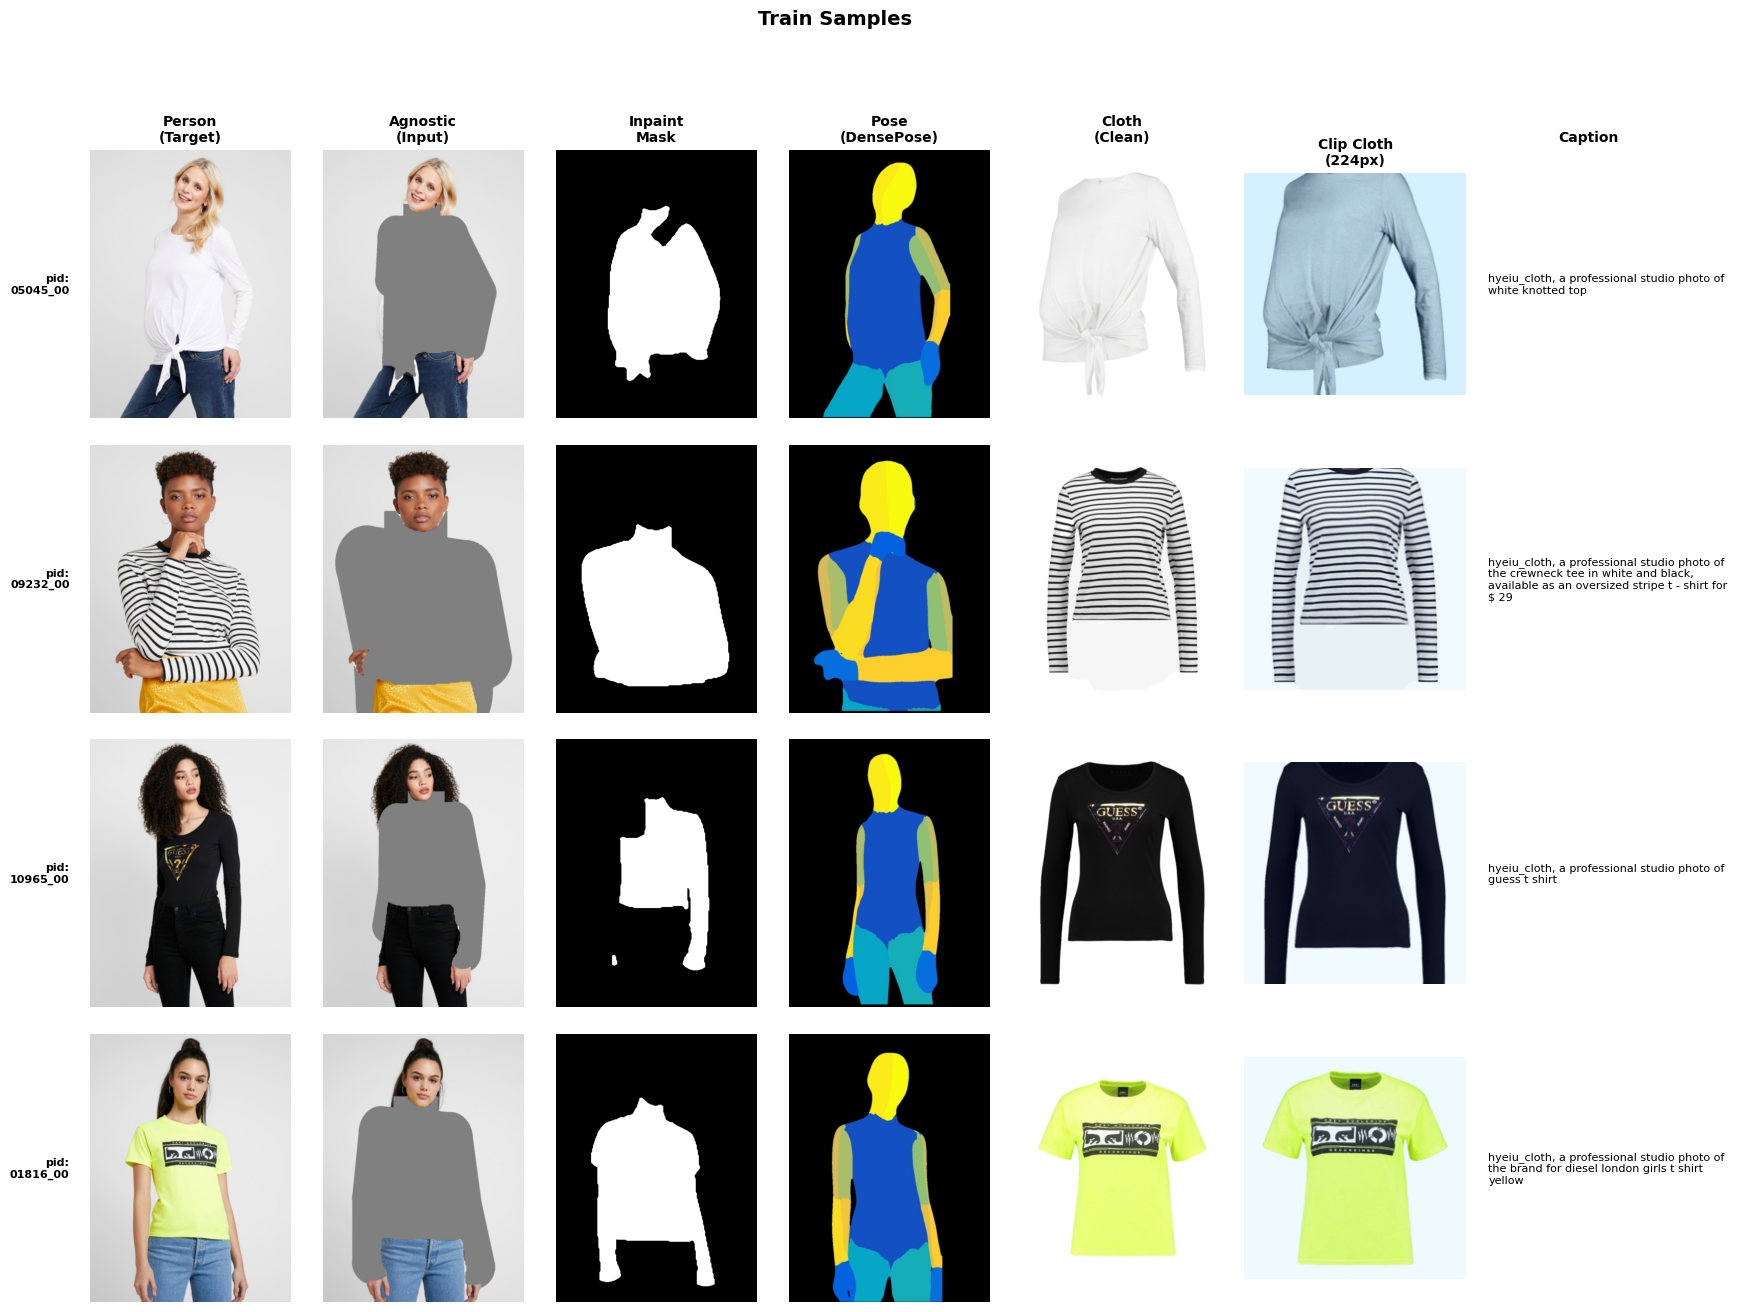

✅ Saved: /kaggle/working/vto_v2/eda_Train_Samples.png


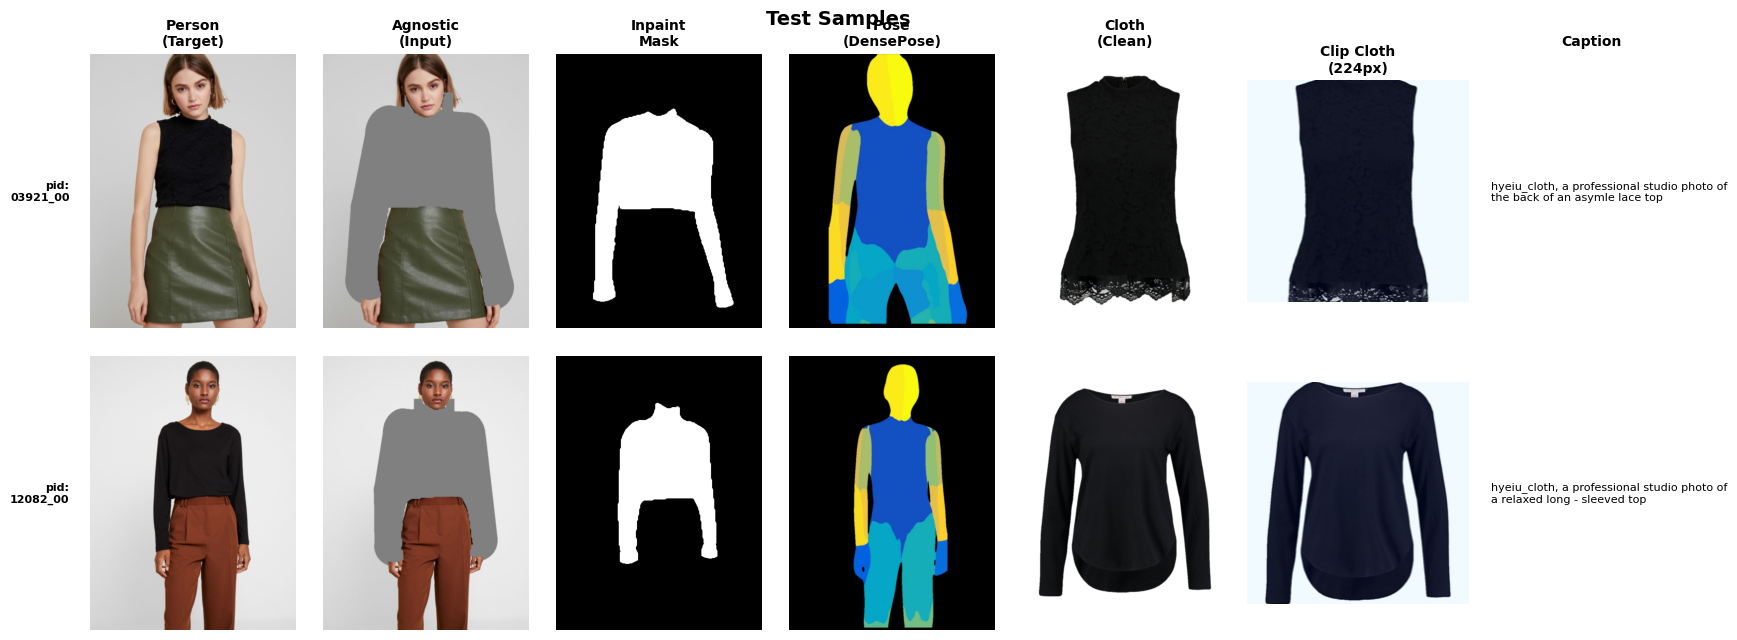

✅ Saved: /kaggle/working/vto_v2/eda_Test_Samples.png

📊 EDA - Analyzing mask statistics...


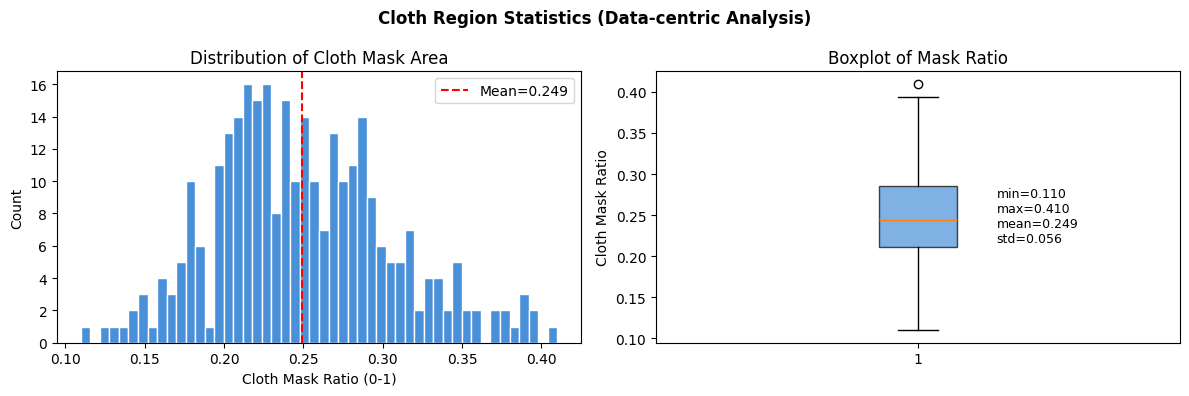

✅ Saved: /kaggle/working/vto_v2/eda_mask_stats.png
   Cloth area covers avg 24.9% của ảnh

📊 EDA - Analyzing captions...


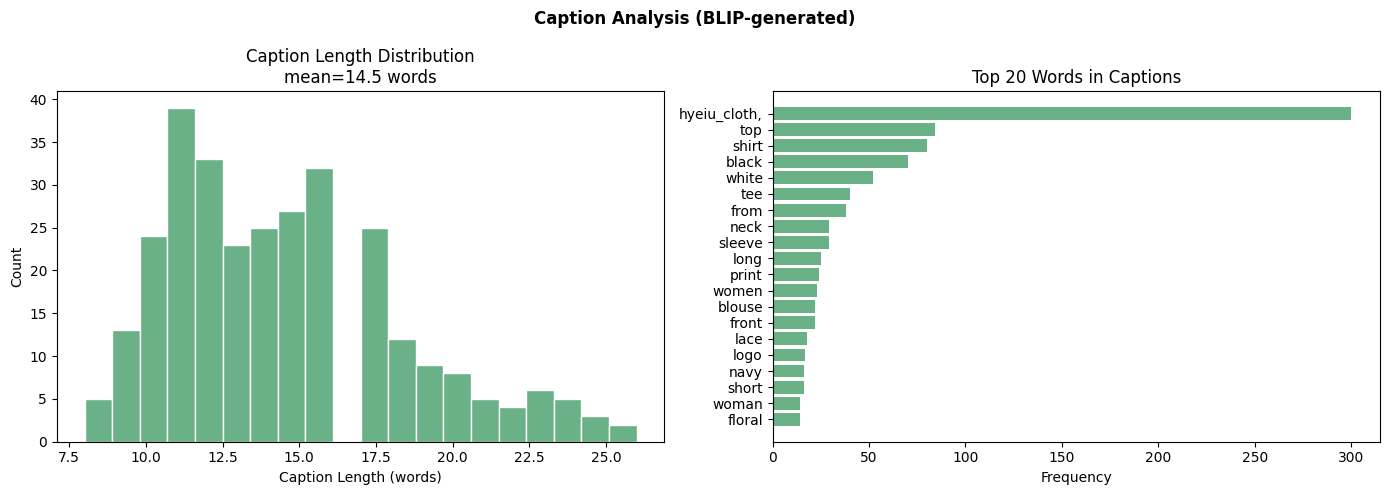

✅ Saved: /kaggle/working/vto_v2/eda_caption_stats.png

✅ EDA hoàn thành! Kết quả lưu ở /kaggle/working/


In [5]:

# ================================================================
# CELL 4: EDA & DATA VISUALIZATION
# Đáp ứng yêu cầu "Phân tích dữ liệu" trong báo cáo
# ================================================================

def audit_vto_data_cells(train_dataset, test_dataset, n=200):
    """
    Kiểm tra nhanh các giả định data mà các cell sau phụ thuộc vào.

    Lưu ý quan trọng:
      - Unpaired test CSV không có GT cho áo target, nên không dùng backward.
      - Val loss dùng paired test_dataset để có GT.
      - Unpaired chỉ dùng Cell 8 để xem qualitative.
    """
    print("=" * 70)
    print("DATA AUDIT FOR TRAINING CELLS")
    print("=" * 70)

    print(f"Image target size : W={cfg.target_w}, H={cfg.target_h}, ratio={cfg.target_w/cfg.target_h:.3f}")
    print(f"Train pairs       : {len(train_dataset):,} paired samples")
    print(f"Val pairs         : {len(test_dataset):,} paired samples")
    print("Train objective   : paired reconstruction, có GT để backward")
    print("Unpaired usage    : qualitative preview only, không backward")

    train_csv = pd.read_csv(CSV_ROOT / "clean_vto_dataset_train.csv")
    test_csv = pd.read_csv(CSV_ROOT / "clean_vto_dataset_test.csv")
    print(f"Train CSV shape   : {train_csv.shape}")
    print(f"Test CSV shape    : {test_csv.shape}")
    print(f"Caption train     : {len(list((CAPTION_ROOT / 'cloth-captions' / 'train').glob('*.txt'))):,} files")
    print(f"Caption test      : {len(list((CAPTION_ROOT / 'cloth-captions' / 'test').glob('*.txt'))):,} files")

    # Folder/filename sanity.
    probe_id = str(train_csv.iloc[0]["id"])
    required_train_files = {
        "image": TRAIN_DIR / "image" / f"{probe_id}.jpg",
        "cloth": TRAIN_DIR / "cloth" / f"{probe_id}.jpg",
        "cloth-mask": TRAIN_DIR / "cloth-mask" / f"{probe_id}.jpg",
        "agnostic-v3.2": TRAIN_DIR / "agnostic-v3.2" / f"{probe_id}.jpg",
        "image-parse-v3": TRAIN_DIR / "image-parse-v3" / f"{probe_id}.png",
        "image-parse-agnostic-v3.2": TRAIN_DIR / "image-parse-agnostic-v3.2" / f"{probe_id}.png",
        "image-densepose": TRAIN_DIR / "image-densepose" / f"{probe_id}.jpg",
        "openpose_img": TRAIN_DIR / "openpose_img" / f"{probe_id}_rendered.png",
    }
    print("\nPath check on first train id:")
    for name, path in required_train_files.items():
        print(f"  {name:28s}: {'OK' if path.exists() else 'MISSING'} {path.name}")

    # Parse-label audit: do not use fixed {4,7}; current dataset often has label 5 for upper cloth.
    parse_path = TRAIN_DIR / "image-parse-v3" / f"{probe_id}.png"
    agnostic_parse_path = TRAIN_DIR / "image-parse-agnostic-v3.2" / f"{probe_id}.png"
    if parse_path.exists() and agnostic_parse_path.exists():
        parse_np = np.array(Image.open(parse_path))
        agn_parse_np = np.array(Image.open(agnostic_parse_path))
        print("\nParse labels on first train id:")
        print(f"  image-parse-v3 labels          : {np.unique(parse_np).tolist()}")
        print(f"  image-parse-agnostic-v3.2 labels: {np.unique(agn_parse_np).tolist()}")
        print("  Mask method used by Cell 3     : parse diff, not fixed labels")

    # Sample processed masks/captions through the same dataset class used for training.
    count = min(n, len(train_dataset))
    indices = random.sample(range(len(train_dataset)), count)
    mask_ratios = []
    missing_caption = 0
    bad_masks = []

    for idx in indices:
        sample = train_dataset[idx]
        ratio = float(sample["inpaint_mask"].mean())
        mask_ratios.append(ratio)
        if sample["caption"].endswith("a photo of a garment"):
            missing_caption += 1
        if ratio < 0.03 or ratio > 0.70:
            bad_masks.append((sample["person_id"], ratio))

    mask_ratios = np.array(mask_ratios)
    print("\nProcessed sample audit:")
    print(f"  checked masks       : {count}")
    print(f"  mask ratio min/mean/max: {mask_ratios.min():.3f} / {mask_ratios.mean():.3f} / {mask_ratios.max():.3f}")
    print(f"  suspicious masks    : {len(bad_masks)}")
    if bad_masks[:8]:
        print(f"  examples            : {bad_masks[:8]}")
    print(f"  fallback captions   : {missing_caption}/{count}")
    print("=" * 70)


def visualize_samples(dataset, n=4, title="Dataset Samples"):
    """Hiển thị n sample với đầy đủ loại ảnh."""
    indices = random.sample(range(len(dataset)), n)
    # Tối ưu figsize để khớp tỷ lệ ảnh 512x384, giúp ảnh không bị thu nhỏ
    fig, axes = plt.subplots(n, 7, figsize=(18, n * 3.2))
    col_titles = ["Person\n(Target)", "Agnostic\n(Input)", "Inpaint\nMask",
                  "Pose\n(DensePose)", "Cloth\n(Clean)", "Clip Cloth\n(224px)", "Caption"]
    for col, ct in enumerate(col_titles):
        axes[0][col].set_title(ct, fontsize=10, fontweight="bold")

    for row_idx, idx in enumerate(indices):
        sample = dataset[idx]
        def to_img(t):
            """[-1,1] tensor → PIL RGB"""
            arr = ((t.permute(1, 2, 0).numpy() + 1) / 2 * 255).clip(0, 255).astype(np.uint8)
            return arr
        def to_mask_img(t):
            arr = (t.squeeze(0).numpy() * 255).clip(0, 255).astype(np.uint8)
            return arr

        panels = [
            to_img(sample["image"]),
            to_img(sample["agnostic"]),
            to_mask_img(sample["inpaint_mask"]),
            to_img(sample["pose"]),
            to_img(sample["cloth"]),
            ((sample["clip_cloth"].permute(1,2,0).numpy() - sample["clip_cloth"].min().item()) /
             (sample["clip_cloth"].max().item() - sample["clip_cloth"].min().item()) * 255).clip(0,255).astype(np.uint8),
        ]
        cmaps = [None, None, "gray", None, None, None]
        for col, (panel, cmap) in enumerate(zip(panels, cmaps)):
            axes[row_idx][col].imshow(panel, cmap=cmap)
            axes[row_idx][col].axis("off")

        # Caption text
        axes[row_idx][6].text(0.05, 0.5, sample["caption"], ha="left", va="center",
                              wrap=True, fontsize=8, transform=axes[row_idx][6].transAxes)
        axes[row_idx][6].axis("off")
        
        # Thêm PID text ở cột đầu tiên
        axes[row_idx][0].text(-0.1, 0.5, f"pid:\n{sample['person_id']}", 
                              ha="right", va="center", fontsize=8, fontweight="bold",
                              transform=axes[row_idx][0].transAxes)

    fig.suptitle(title, fontsize=14, fontweight="bold", y=0.95 + (0.02 * n))
    # Dùng subplots_adjust thay vì tight_layout để tránh bị bug khoảng cách
    plt.subplots_adjust(wspace=0.05, hspace=0.1, top=0.92, bottom=0.02, left=0.08, right=0.98)
    
    out = OUTPUT_DIR / f"eda_{title.replace(' ', '_')}.png"
    plt.savefig(out, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"✅ Saved: {out}")


def analyze_mask_stats(dataset, n=500):
    """Thống kê diện tích mask (vùng áo) để hiểu phân phối."""
    ratios = []
    for idx in random.sample(range(len(dataset)), min(n, len(dataset))):
        sample = dataset[idx]
        mask = sample["inpaint_mask"].numpy()
        ratios.append(mask.mean())

    ratios = np.array(ratios)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(ratios, bins=50, color="#4A90D9", edgecolor="white")
    axes[0].axvline(ratios.mean(), color="red", linestyle="--", label=f"Mean={ratios.mean():.3f}")
    axes[0].set_xlabel("Cloth Mask Ratio (0-1)")
    axes[0].set_ylabel("Count")
    axes[0].set_title("Distribution of Cloth Mask Area")
    axes[0].legend()

    axes[1].boxplot(ratios, vert=True, patch_artist=True,
                    boxprops=dict(facecolor="#4A90D9", alpha=0.7))
    axes[1].set_ylabel("Cloth Mask Ratio")
    axes[1].set_title("Boxplot of Mask Ratio")
    stats_text = f"min={ratios.min():.3f}\nmax={ratios.max():.3f}\nmean={ratios.mean():.3f}\nstd={ratios.std():.3f}"
    axes[1].text(1.15, ratios.mean(), stats_text, fontsize=9, va="center")

    plt.suptitle("Cloth Region Statistics (Data-centric Analysis)", fontsize=12, fontweight="bold")
    plt.tight_layout()
    out = OUTPUT_DIR / "eda_mask_stats.png"
    plt.savefig(out, dpi=100, bbox_inches="tight")
    plt.show()
    print(f"✅ Saved: {out}")
    return ratios


def analyze_caption_stats(dataset, n=500):
    """Phân tích caption: độ dài, từ phổ biến."""
    captions = [dataset[i]["caption"] for i in random.sample(range(len(dataset)), min(n, len(dataset)))]
    lengths  = [len(c.split()) for c in captions]

    # Top words (bỏ stopwords)
    stopwords = {"a", "an", "the", "of", "in", "with", "and", "for", "is", "are",
                 "photo", "professional", "studio", "hyeiu_cloth"}
    word_counts = defaultdict(int)
    for cap in captions:
        for w in cap.lower().split():
            if w not in stopwords and len(w) > 2:
                word_counts[w] += 1
    top_words = sorted(word_counts.items(), key=lambda x: -x[1])[:20]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].hist(lengths, bins=20, color="#6AB187", edgecolor="white")
    axes[0].set_xlabel("Caption Length (words)")
    axes[0].set_ylabel("Count")
    axes[0].set_title(f"Caption Length Distribution\nmean={np.mean(lengths):.1f} words")

    words, counts = zip(*top_words)
    axes[1].barh(list(words)[::-1], list(counts)[::-1], color="#6AB187")
    axes[1].set_xlabel("Frequency")
    axes[1].set_title("Top 20 Words in Captions")

    plt.suptitle("Caption Analysis (BLIP-generated)", fontsize=12, fontweight="bold")
    plt.tight_layout()
    out = OUTPUT_DIR / "eda_caption_stats.png"
    plt.savefig(out, dpi=100, bbox_inches="tight")
    plt.show()
    print(f"✅ Saved: {out}")


# ── Chạy EDA ─────────────────────────────────────────────────────
audit_vto_data_cells(train_ds, test_ds, n=200)

print("📊 EDA - Visualizing samples...")
visualize_samples(train_ds, n=4, title="Train Samples")
visualize_samples(test_ds,  n=2, title="Test Samples")

print("\n📊 EDA - Analyzing mask statistics...")
mask_ratios = analyze_mask_stats(train_ds, n=300)
print(f"   Cloth area covers avg {mask_ratios.mean()*100:.1f}% của ảnh")

print("\n📊 EDA - Analyzing captions...")
analyze_caption_stats(train_ds, n=300)

print("\n✅ EDA hoàn thành! Kết quả lưu ở /kaggle/working/")


In [6]:

# ================================================================
# CELL 5: MODEL DEFINITION
# 1. PerceiverResampler    (CLIP patches → global cloth tokens)
# 2. ClothSpatialProjector (VAE latent  → spatial cloth tokens)
# 3. UNet 9ch → 13ch expansion
# 4. Load & configure tất cả components
# ================================================================

# ── 1. Perceiver Resampler ────────────────────────────────────────
class PerceiverResampler(nn.Module):
    """
    Chắt lọc 257 CLIP patch tokens → N global cloth tokens.
    Dùng Cross-Attention: N learnable latent queries attend vào CLIP patches.
    Inspired by IP-Adapter Plus & Flamingo.

    Input : CLIP last_hidden_state [B, 257, 1024]
    Output: cloth tokens           [B, N, 768]
    """
    def __init__(self, input_dim=1024, output_dim=768,
                 num_queries=16, depth=4, num_heads=8):
        super().__init__()
        self.latents = nn.Parameter(torch.randn(1, num_queries, input_dim) * 0.02)
        self.layers  = nn.ModuleList([
            nn.ModuleList([
                nn.LayerNorm(input_dim),
                nn.MultiheadAttention(input_dim, num_heads, batch_first=True, dropout=0.0),
                nn.LayerNorm(input_dim),
                nn.MultiheadAttention(input_dim, num_heads, batch_first=True, dropout=0.0),
                nn.LayerNorm(input_dim),
                nn.Sequential(
                    nn.Linear(input_dim, input_dim * 4), nn.GELU(),
                    nn.Linear(input_dim * 4, input_dim)
                ),
            ])
            for _ in range(depth)
        ])
        self.norm_out = nn.LayerNorm(input_dim)
        self.proj_out = nn.Linear(input_dim, output_dim)

    def forward(self, clip_patches):  # clip_patches: [B, 257, 1024]
        x = self.latents.expand(clip_patches.shape[0], -1, -1)
        for norm1, sa, norm2, ca, norm3, ff in self.layers:
            x = x + sa(norm1(x), norm1(x), norm1(x))[0]    # Self-Attn
            x = x + ca(norm2(x), clip_patches, clip_patches)[0]  # Cross-Attn
            x = x + ff(norm3(x))                            # FFN
        return self.proj_out(self.norm_out(x))               # [B, N, 768]


# ── 2. Cloth Spatial Projector ────────────────────────────────────
class ClothSpatialProjector(nn.Module):
    """
    Trích xuất spatial features từ VAE latent của áo.
    Khác với Perceiver (global semantic), module này giữ thông tin
    vị trí không gian (cổ áo ở đâu, tay áo ở đâu).

    Input : cloth VAE latent [B, 4, H/8, W/8]
    Output: spatial tokens   [B, 64, 768]  (grid 8×8)
    """
    def __init__(self, in_ch=4, out_dim=768):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, 64,  3, padding=1), nn.GELU(),
            nn.Conv2d(64,  128, 3, stride=2, padding=1), nn.GELU(),
            nn.Conv2d(128, 256, 3, stride=2, padding=1), nn.GELU(),
            nn.AdaptiveAvgPool2d((8, 8)),  # → 8×8 = 64 spatial tokens
        )
        self.proj = nn.Linear(256, out_dim)
        self.norm = nn.LayerNorm(out_dim)

    def forward(self, cloth_lat):  # [B, 4, h, w]
        x = self.conv(cloth_lat.float())   # [B, 256, 8, 8]
        x = x.flatten(2).permute(0, 2, 1) # [B, 64, 256]
        return self.norm(self.proj(x))     # [B, 64, 768]


# ── 3. Expand UNet 9ch → 17ch ─────────────────────────────────────
def expand_unet_conv_in(unet, new_channels=17):
    """
    Mở rộng lớp conv_in của UNet từ 9 kênh → 17 kênh.
    8 kênh mới (pose + cloth latent) được zero-init để không phá
    vỡ trọng số pretrained. conv_in sẽ được train và lưu riêng,
    vì đây là cửa vào trực tiếp của cloth latent.

    17 kênh input:
    [0:4]  - Noisy latent (ảnh nhiễu)
    [4:5]  - Inpaint mask (1 kênh)
    [5:9]  - Agnostic latent (nền)
    [9:13] - Pose/DensePose latent (NEW)
    [13:17]- Cloth latent target (NEW, low-level garment condition)
    """
    # Truy cập model gốc qua PEFT wrapper
    base = unet.base_model.model if hasattr(unet, "base_model") else unet
    old_conv = base.conv_in

    new_conv = nn.Conv2d(
        new_channels, old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        padding=old_conv.padding,
        bias=(old_conv.bias is not None)
    )

    with torch.no_grad():
        # Copy trọng số 9 kênh cũ
        new_conv.weight[:, :9]  = old_conv.weight.clone()
        # Zero-init các kênh condition mới (neutral start)
        new_conv.weight[:, 9:]  = 0.0
        if old_conv.bias is not None:
            new_conv.bias.copy_(old_conv.bias)

    base.conv_in = new_conv
    base.config["in_channels"] = new_channels
    print(f"✅ UNet conv_in: 9ch → {new_channels}ch (new condition channels zero-initialized)")
    return unet


# ── 4. Load All Components ─────────────────────────────────────────
print("=" * 55)
print("Loading Model Components")
print("=" * 55)

dtype = torch.float16  # FP16 cho T4

print("  [1/5] Loading VAE...")
vae = AutoencoderKL.from_pretrained(
    cfg.model_id, subfolder="vae", torch_dtype=dtype)
vae.enable_slicing()
vae.enable_tiling()
vae.requires_grad_(False)
vae.eval()

print("  [2/5] Loading Text Encoder...")
text_encoder = CLIPTextModel.from_pretrained(
    cfg.model_id, subfolder="text_encoder", torch_dtype=dtype)
text_encoder.requires_grad_(False)
text_encoder.eval()

print("  [3/5] Loading UNet...")
unet = UNet2DConditionModel.from_pretrained(
    cfg.model_id, subfolder="unet", torch_dtype=dtype)
unet.enable_gradient_checkpointing()

# Áp dụng LoRA
lora_config = LoraConfig(
    r=cfg.lora_rank,
    lora_alpha=cfg.lora_alpha,
    target_modules=cfg.lora_targets,
    lora_dropout=cfg.lora_dropout,
    bias="none",
)
unet = get_peft_model(unet, lora_config)
unet.print_trainable_parameters()

# Mở rộng 9ch → 17ch
unet = expand_unet_conv_in(unet, new_channels=cfg.unet_in_channels)
unet.base_model.model.conv_in.requires_grad_(True)
print("  ✅ conv_in trainable and will be saved as conv_in.pt")

try:
    unet.enable_xformers_memory_efficient_attention()
    print("  ✅ xformers enabled")
except Exception as e:
    print(f"  ⚠️  xformers not available: {e}")

print("  [4/5] Loading CLIP Vision Encoder...")
image_encoder = CLIPVisionModelWithProjection.from_pretrained(
    cfg.ip_adapter_id,
    subfolder="models/image_encoder",
    torch_dtype=dtype
)
image_encoder.requires_grad_(False)
image_encoder.eval()

print("  [5/5] Loading Noise Scheduler...")
noise_scheduler = DDPMScheduler.from_pretrained(cfg.model_id, subfolder="scheduler")

# ── Custom modules (trainable) ─────────────────────────────────────
# Lấy cross-attention dim từ UNet config
cross_attn_dim = unet.base_model.model.config.cross_attention_dim  # 768

# Detect CLIP hidden dim (ViT-L/14 = 1024)
with torch.no_grad():
    dummy = torch.zeros(1, 3, 224, 224, dtype=dtype)
    clip_dim = image_encoder(
        pixel_values=dummy.to(next(image_encoder.parameters()).device),
        output_hidden_states=True
    ).last_hidden_state.shape[-1]
    print(f"  CLIP hidden dim: {clip_dim}")

perceiver = PerceiverResampler(
    input_dim=clip_dim,
    output_dim=cross_attn_dim,
    num_queries=cfg.num_image_tokens,
    depth=cfg.perceiver_depth,
    num_heads=cfg.perceiver_heads,
).float()  # FP32 để ổn định training

cloth_spatial_proj = ClothSpatialProjector(
    in_ch=4,
    out_dim=cross_attn_dim,
).float()

# ── Parameter count ────────────────────────────────────────────────
n_lora  = sum(p.numel() for p in unet.parameters() if p.requires_grad)
n_perc  = sum(p.numel() for p in perceiver.parameters())
n_spat  = sum(p.numel() for p in cloth_spatial_proj.parameters())
n_total = n_lora + n_perc + n_spat

print(f"\n📊 Trainable Parameters:")
print(f"   LoRA (UNet)      : {n_lora:>12,}  ({n_lora/1e6:.2f}M)")
print(f"   Perceiver        : {n_perc:>12,}  ({n_perc/1e6:.2f}M)")
print(f"   ClothSpatialProj : {n_spat:>12,}  ({n_spat/1e6:.2f}M)")
print(f"   {'─'*40}")
print(f"   TOTAL trainable  : {n_total:>12,}  ({n_total/1e6:.2f}M)")

total_unet = sum(p.numel() for p in unet.parameters())
print(f"   Full UNet size   : {total_unet:>12,}  ({total_unet/1e6:.2f}M)")
print(f"   LoRA ratio       : {n_lora/total_unet*100:.2f}%")
print(f"\n✅ Models ready!")


Loading Model Components
  [1/5] Loading VAE...


config.json:   0%|          | 0.00/552 [00:00<?, ?B/s]

An error occurred while trying to fetch runwayml/stable-diffusion-inpainting: runwayml/stable-diffusion-inpainting does not appear to have a file named diffusion_pytorch_model.safetensors.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


vae/diffusion_pytorch_model.bin:   0%|          | 0.00/335M [00:00<?, ?B/s]

  [2/5] Loading Text Encoder...


...

config.json:   0%|          | 0.00/560 [00:00<?, ?B/s]

models/image_encoder/model.safetensors:   0%|          | 0.00/2.53G [00:00<?, ?B/s]

  [5/5] Loading Noise Scheduler...


scheduler_config.json:   0%|          | 0.00/313 [00:00<?, ?B/s]

  CLIP hidden dim: 1280

📊 Trainable Parameters:
   LoRA (UNet)      :    6,033,536  (6.03M)
   Perceiver        :   53,474,048  (53.47M)
   ClothSpatialProj :      570,304  (0.57M)
   ────────────────────────────────────────
   TOTAL trainable  :   60,077,888  (60.08M)
   Full UNet size   :  865,542,660  (865.54M)
   LoRA ratio       : 0.70%

✅ Models ready!


In [7]:

# ================================================================
# CELL 6: TRAINING SETUP
# DataLoader, Optimizer, Scheduler, W&B, Accelerator
# ================================================================

# ── Đọc W&B API Key từ Kaggle Secrets ────────────────────────────
import wandb
from kaggle_secrets import UserSecretsClient

try:
    secrets = UserSecretsClient()
    wandb_key = secrets.get_secret("WANDB_API_KEY")
    wandb.login(key=wandb_key)
    print("✅ W&B login thành công từ Kaggle Secrets")
except Exception as e:
    print(f"⚠️  Không đọc được Kaggle Secret: {e}")
    print("   → Thử login thủ công hoặc đặt use_wandb=False trong Config")


# ── DataLoaders ───────────────────────────────────────────────────
train_loader = DataLoader(
    train_ds,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=cfg.num_workers,
    pin_memory=True,
    drop_last=True,
    persistent_workers=(cfg.num_workers > 0),
)

test_loader = DataLoader(
    test_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=True,
)

print(f"✅ DataLoaders:")
print(f"   Train batches: {len(train_loader):,}")
print(f"   Test  batches: {len(test_loader):,}")

# ── Optimizer ─────────────────────────────────────────────────────
# conv_in chứa 8 kênh condition mới (pose + cloth latent), trong đó 4 kênh
# cloth latent đang học yếu hơn token. Cho conv_in LR riêng để áo target có
# lực tác động rõ hơn mà không làm LoRA/Perceiver quá hung.
conv_in_params = list(unet.base_model.model.conv_in.parameters())
conv_in_param_ids = {id(p) for p in conv_in_params}
unet_lora_params = [
    p for p in unet.parameters()
    if p.requires_grad and id(p) not in conv_in_param_ids
]
perceiver_params = list(perceiver.parameters())
spatial_params = list(cloth_spatial_proj.parameters())

all_params = unet_lora_params + conv_in_params + perceiver_params + spatial_params

optimizer = torch.optim.AdamW(
    [
        {"params": unet_lora_params, "lr": cfg.lr, "name": "unet_lora"},
        {"params": conv_in_params, "lr": cfg.conv_in_lr, "name": "conv_in"},
        {"params": perceiver_params, "lr": cfg.lr, "name": "perceiver"},
        {"params": spatial_params, "lr": cfg.lr, "name": "cloth_spatial"},
    ],
    weight_decay=cfg.weight_decay,
    betas=(0.9, 0.999),
    eps=1e-8,
)

# ── LR Scheduler (Cosine với Warmup) ─────────────────────────────
total_steps = (len(train_loader) // cfg.grad_accum) * cfg.num_epochs
lr_scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=cfg.warmup_steps,
    num_training_steps=total_steps,
)
print(f"\n✅ Optimizer: AdamW  base_lr={cfg.lr}  conv_in_lr={cfg.conv_in_lr}  wd={cfg.weight_decay}")
print(f"   Param groups: LoRA={len(unet_lora_params):,} tensors | conv_in={len(conv_in_params):,} tensors | "
      f"perceiver={len(perceiver_params):,} tensors | spatial={len(spatial_params):,} tensors")
print(f"   Scheduler : Cosine warmup  ({cfg.warmup_steps} steps warm / {total_steps} total)")

# ── Accelerator (Multi-GPU T4x2) ──────────────────────────────────
accelerator = Accelerator(
    gradient_accumulation_steps=cfg.grad_accum,
    mixed_precision="fp16",
    log_with="wandb" if cfg.use_wandb else None,
)

# ── W&B Init ──────────────────────────────────────────────────────
if cfg.use_wandb and accelerator.is_main_process:
    wandb.init(
        project=cfg.wandb_project,
        name=cfg.wandb_run_name,
        config={
            "model_id"       : cfg.model_id,
            "target_size"    : f"{cfg.target_w}x{cfg.target_h}",
            "batch_size"     : cfg.batch_size,
            "grad_accum"     : cfg.grad_accum,
            "effective_batch": cfg.batch_size * cfg.grad_accum,
            "num_epochs"     : cfg.num_epochs,
            "lr"             : cfg.lr,
            "conv_in_lr"     : cfg.conv_in_lr,
            "lora_rank"      : cfg.lora_rank,
            "lora_alpha"     : cfg.lora_alpha,
            "unet_channels"  : cfg.unet_in_channels,
            "num_img_tokens" : cfg.num_image_tokens,
            "min_snr_gamma"  : cfg.min_snr_gamma,
            "mask_loss_weight": cfg.mask_loss_weight,
            "x0_latent_loss_weight": cfg.x0_latent_loss_weight,
            "x0_mask_loss_weight": cfg.x0_mask_loss_weight,
            "cfg_drop_text"  : cfg.cfg_drop_text,
            "cfg_drop_cloth" : cfg.cfg_drop_cloth,
            "ema_decay"      : cfg.ema_decay,
            "seed"           : cfg.seed,
            "n_trainable_M"  : (n_lora + n_perc + n_spat) / 1e6,
        },
        dir=str(OUTPUT_DIR),
    )
    print(f"✅ W&B initialized: project={cfg.wandb_project}")

# ── Accelerator Prepare ───────────────────────────────────────────
(unet, perceiver, cloth_spatial_proj,
 optimizer, train_loader, test_loader,
 lr_scheduler) = accelerator.prepare(
    unet, perceiver, cloth_spatial_proj,
    optimizer, train_loader, test_loader,
    lr_scheduler
)

# Các model frozen cần manually move to device
DEVICE = accelerator.device
vae          = vae.to(DEVICE)
text_encoder = text_encoder.to(DEVICE)
image_encoder= image_encoder.to(DEVICE)

# ── EMA Wrappers ──────────────────────────────────────────────────
ema_unet    = AveragedModel(accelerator.unwrap_model(unet),
                            multi_avg_fn=get_ema_multi_avg_fn(cfg.ema_decay))
ema_perc    = AveragedModel(accelerator.unwrap_model(perceiver),
                            multi_avg_fn=get_ema_multi_avg_fn(cfg.ema_decay))
ema_spatial = AveragedModel(accelerator.unwrap_model(cloth_spatial_proj),
                            multi_avg_fn=get_ema_multi_avg_fn(cfg.ema_decay))

# ── Min-SNR precompute ────────────────────────────────────────────
alphas_cumprod = noise_scheduler.alphas_cumprod  # on CPU

def compute_snr_weights(timesteps):
    """
    Min-SNR Loss Weighting (Hang et al., 2023).
    Cân bằng gradient ở các mức nhiễu khác nhau,
    giúp hội tụ nhanh hơn ~2x so với MSE thuần.
    w = min(SNR, γ) / SNR
    """
    ac  = alphas_cumprod.to(timesteps.device)[timesteps]
    snr = ac / (1.0 - ac)
    w   = torch.minimum(snr, torch.full_like(snr, cfg.min_snr_gamma)) / snr
    return w

# ── Training State ────────────────────────────────────────────────
global_step       = 0
best_val_loss     = float("inf")
no_improve_count  = 0
loss_history      = []
train_epoch_losses= []
val_epoch_losses  = []

print(f"\n✅ Training setup done!")
print(f"   Device     : {DEVICE}")
print(f"   Num GPUs   : {accelerator.num_processes}")
print(f"   Mixed prec : {accelerator.mixed_precision}")


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: yennguyen140205 (yennguyen140205-tr-ng-i-h-c-khoa-h-c-t-nhi-n-hqg-hcm) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


✅ W&B login thành công từ Kaggle Secrets
✅ DataLoaders:
   Train batches: 9,520
   Test  batches: 996

✅ Optimizer: AdamW  base_lr=2e-05  conv_in_lr=0.0001  wd=0.0001
   Param groups: LoRA=320 tensors | conv_in=2 tensors | perceiver=41 tensors | spatial=10 tensors
   Scheduler : Cosine warmup  (200 steps warm / 23800 total)


✅ W&B initialized: project=VTO-Model4-SD-LoRA

✅ Training setup done!
   Device     : cuda
   Num GPUs   : 1
   Mixed prec : fp16


In [ ]:

# ================================================================
# CELL 7: TRAINING LOOP (CHÍNH THỨC)
# - Full dataset, resume tự động, zip mỗi epoch
# ================================================================

from tqdm.auto import tqdm
import random, json, gc, shutil, zipfile, time
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from pathlib import Path

# ── Cấu hình train chính thức ────────────────────────────────────
TEST_RUN = False        # ← FALSE = train chính thức
ZIP_EVERY_EPOCH = True  # Zip sau mỗi epoch để tải về

# ── Forward pass ─────────────────────────────────────────────────
def forward_pass(batch, training=True):
    pv   = batch["image"].to(DEVICE, dtype=torch.float16)
    agn  = batch["agnostic"].to(DEVICE, dtype=torch.float16)
    pose = batch["pose"].to(DEVICE, dtype=torch.float16)
    cloth= batch["cloth"].to(DEVICE, dtype=torch.float16)
    mask = batch["inpaint_mask"].to(DEVICE, dtype=torch.float16)
    clip_cloth = batch["clip_cloth"].to(DEVICE, dtype=torch.float16)
    ids  = batch["input_ids"].to(DEVICE)

    with torch.no_grad():
        text_emb    = text_encoder(ids)[0]
        clip_patches= image_encoder(pixel_values=clip_cloth, output_hidden_states=True).last_hidden_state

    drop_cloth_tokens = training and random.random() < cfg.cfg_drop_cloth

    if training:
        if random.random() < cfg.cfg_drop_text:   text_emb = torch.zeros_like(text_emb)

    cloth_tokens  = perceiver(clip_patches.float()).to(torch.float16)

    with torch.no_grad():
        lat  = vae.encode(pv).latent_dist.sample()   * cfg.vae_scale
        mlat = vae.encode(agn).latent_dist.sample()  * cfg.vae_scale
        plat = vae.encode(pose).latent_dist.sample() * cfg.vae_scale
        clat = vae.encode(cloth).latent_dist.mode()  * cfg.vae_scale

    cloth_spatial = cloth_spatial_proj(clat.float()).to(torch.float16)
    if drop_cloth_tokens:
        # Drop token/spatial branch nhẹ để model buộc phải học đường cloth latent 17ch.
        # Không drop clat trong model_input.
        cloth_tokens = torch.zeros_like(cloth_tokens)
        cloth_spatial = torch.zeros_like(cloth_spatial)
    enc_hs = torch.cat([text_emb, cloth_tokens, cloth_spatial], dim=1)

    noise     = torch.randn_like(lat)
    timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps,
                              (lat.shape[0],), device=DEVICE).long()
    noisy_lat = noise_scheduler.add_noise(lat, noise, timesteps)

    mask_down   = F.interpolate(mask, size=lat.shape[-2:], mode="nearest")
    # 17ch input: noisy latent + mask + agnostic latent + pose latent + target cloth latent.
    # The last 4 channels give UNet a direct low-level garment signal, not only CLIP/text tokens.
    model_input = torch.cat([noisy_lat, mask_down, mlat, plat, clat], dim=1)

    noise_pred  = unet(model_input, timesteps, encoder_hidden_states=enc_hs).sample

    loss_map   = F.mse_loss(noise_pred.float(), noise.float(), reduction="none")
    mask_w     = 1.0 + cfg.mask_loss_weight * mask_down.float()
    noise_loss = (loss_map * mask_w).mean(dim=[1, 2, 3])

    # Auxiliary x0 latent reconstruction loss.
    # Noise loss thấp chưa chắc áo đúng; loss này ép dự đoán x0 giống GT latent
    # trong vùng áo, rẻ hơn decode pixel loss và chạy ổn trên T4.
    alphas = noise_scheduler.alphas_cumprod.to(DEVICE, dtype=torch.float32)
    alpha_t = alphas[timesteps].view(-1, 1, 1, 1).clamp(min=1e-8)
    beta_t = (1.0 - alpha_t).clamp(min=1e-8)
    pred_x0 = (noisy_lat.float() - beta_t.sqrt() * noise_pred.float()) / alpha_t.sqrt()
    x0_w = 0.2 + cfg.x0_mask_loss_weight * mask_down.float()
    x0_loss = (F.l1_loss(pred_x0, lat.float(), reduction="none") * x0_w).mean(dim=[1, 2, 3])

    pixel_loss = noise_loss + cfg.x0_latent_loss_weight * x0_loss

    # Dùng cùng công thức loss cho train/val để log val không bị lệch scale.
    if cfg.min_snr_gamma > 0:
        snr_w = compute_snr_weights(timesteps)
        loss  = (pixel_loss * snr_w).mean()
    else:
        loss  = pixel_loss.mean()

    return loss


# ── Resume detection ──────────────────────────────────────────────
CKPT_LATEST = OUTPUT_DIR / "checkpoint_latest"
RESUME_FILE  = OUTPUT_DIR / "loss_history.json"

start_epoch      = 0
global_step      = 0
best_val_loss    = float("inf")
no_improve_count = 0
loss_history     = []
train_epoch_losses = []
val_epoch_losses   = []

if CKPT_LATEST.exists() and (CKPT_LATEST / "perceiver.pt").exists() and (CKPT_LATEST / "conv_in.pt").exists():
    print("=" * 55)
    print("📂 PHÁT HIỆN CHECKPOINT — ĐANG RESUME")
    print("=" * 55)
    try:
        # Load LoRA vào adapter "default" đã tồn tại từ Cell 5.
        # Không tạo adapter mới vì optimizer ở Cell 6 đã giữ references tới adapter này.
        unwrapped_unet = accelerator.unwrap_model(unet)
        lora_path = CKPT_LATEST / "unet_lora" / "adapter_model.safetensors"
        lora_state = load_safetensors(str(lora_path), device="cpu")
        set_peft_model_state_dict(unwrapped_unet, lora_state, adapter_name="default")
        # Load Perceiver
        accelerator.unwrap_model(perceiver).load_state_dict(
            torch.load(CKPT_LATEST / "perceiver.pt", map_location=DEVICE)
        )
        # Load trainable conv_in mở rộng 17ch nếu checkpoint mới có lưu.
        if (CKPT_LATEST / "conv_in.pt").exists():
            accelerator.unwrap_model(unet).base_model.model.conv_in.load_state_dict(
                torch.load(CKPT_LATEST / "conv_in.pt", map_location=DEVICE)
            )
        # Load Spatial Projector
        accelerator.unwrap_model(cloth_spatial_proj).load_state_dict(
            torch.load(CKPT_LATEST / "cloth_spatial.pt", map_location=DEVICE)
        )
        # Load EMA — chỉ load LoRA delta (khớp với format lưu mới)
        ema_lora_path = CKPT_LATEST / "ema_unet_lora.pt"
        if ema_lora_path.exists():
            # Format mới: chỉ có LoRA delta keys
            ema_lora_dict = torch.load(ema_lora_path, map_location=DEVICE)
            # Cập nhật đúng các key LoRA trong EMA state dict
            full_ema_state = ema_unet.module.state_dict()
            full_ema_state.update(ema_lora_dict)
            ema_unet.module.load_state_dict(full_ema_state)
        elif (CKPT_LATEST / "ema_unet.pt").exists():
            # Format cũ (epoch 1 đã train trước): full UNet state dict
            ema_unet.module.load_state_dict(
                torch.load(CKPT_LATEST / "ema_unet.pt", map_location=DEVICE)
            )
        if (CKPT_LATEST / "ema_perceiver.pt").exists():
            ema_perc.module.load_state_dict(
                torch.load(CKPT_LATEST / "ema_perceiver.pt", map_location=DEVICE)
            )
        else:
            ema_perc.module.load_state_dict(accelerator.unwrap_model(perceiver).state_dict())

        if (CKPT_LATEST / "ema_cloth_spatial.pt").exists():
            ema_spatial.module.load_state_dict(
                torch.load(CKPT_LATEST / "ema_cloth_spatial.pt", map_location=DEVICE)
            )
        else:
            ema_spatial.module.load_state_dict(accelerator.unwrap_model(cloth_spatial_proj).state_dict())
        # Load training state
        if not RESUME_FILE.exists():
            raise FileNotFoundError(
                f"Thiếu {RESUME_FILE}; không xác định được epoch/global_step để resume an toàn."
            )

        with open(RESUME_FILE) as f:
            hist = json.load(f)
        train_epoch_losses = hist.get("epoch_train_losses", [])
        val_epoch_losses   = hist.get("epoch_val_losses",   [])
        best_val_loss      = hist.get("best_val_loss", float("inf"))
        global_step        = int(hist.get("global_step", 0))
        start_epoch        = int(hist.get("epochs_done", 0))
        loss_history       = hist.get("step_losses", [])
        no_improve_count   = int(hist.get("no_improve_count", 0))

        if start_epoch <= 0 or global_step <= 0:
            raise ValueError(
                f"Metadata resume không hợp lệ: epochs_done={start_epoch}, global_step={global_step}"
            )

        old_cfg = hist.get("config", {})
        compatibility_keys = [
            "unet_in_channels", "lora_rank", "lora_alpha",
            "num_image_tokens", "perceiver_depth", "perceiver_heads",
            "lr", "conv_in_lr", "x0_latent_loss_weight",
            "x0_mask_loss_weight", "cfg_drop_cloth",
        ]
        mismatches = []
        for key in compatibility_keys:
            if key in old_cfg and str(getattr(cfg, key)) != str(old_cfg[key]):
                mismatches.append(f"{key}: checkpoint={old_cfg[key]} current={getattr(cfg, key)}")
        if mismatches:
            raise ValueError("Config resume không khớp:\n  " + "\n  ".join(mismatches))

        ema_conv_in_path = CKPT_LATEST / "ema_conv_in.pt"
        if ema_conv_in_path.exists():
            ema_unet.module.base_model.model.conv_in.load_state_dict(
                torch.load(ema_conv_in_path, map_location=DEVICE)
            )
        else:
            # Epoch 3 cũ chưa lưu EMA conv_in: khởi tạo EMA conv_in từ live checkpoint.
            ema_unet.module.base_model.model.conv_in.load_state_dict(
                accelerator.unwrap_model(unet).base_model.model.conv_in.state_dict()
            )

        raw_lr_scheduler = getattr(lr_scheduler, "scheduler", lr_scheduler)
        scheduler_path = CKPT_LATEST / "lr_scheduler.pt"
        if scheduler_path.exists():
            raw_lr_scheduler.load_state_dict(torch.load(scheduler_path, map_location="cpu"))
            print("     LR scheduler state loaded")
        elif global_step > 0:
            # Checkpoint cũ chưa lưu scheduler: đưa cosine schedule về đúng global_step.
            raw_lr_scheduler.step(global_step)
            print(f"     LR scheduler aligned to global_step={global_step}")

        print(f"  ✅ Resume thành công từ epoch {start_epoch}")
        print(f"     global_step = {global_step}")
        print(f"     best_val_loss = {best_val_loss:.6f}")
    except Exception as e:
        raise RuntimeError(f"Resume thất bại; dừng để tránh train sai: {e}") from e
else:
    if RESUME_EPOCH is not None:
        raise FileNotFoundError(
            f"RESUME_EPOCH={RESUME_EPOCH} nhưng không tìm thấy checkpoint hợp lệ tại {CKPT_LATEST}."
        )
    print("🆕 Bắt đầu training từ đầu (RESUME_EPOCH=None)")


# ── Zip helper ────────────────────────────────────────────────────
def zip_checkpoint(epoch_num):
    """
    Zip toàn bộ files cần thiết để resume sau.
    Nội dung zip tối giản: unet_lora/, conv_in.pt, perceiver.pt,
                           cloth_spatial.pt, ema_unet_lora.pt, ema_conv_in.pt,
                           lr_scheduler.pt, loss_history.json
    """
    zip_path = OUTPUT_DIR / f"checkpoint_epoch_{epoch_num:02d}.zip"
    essential = [
        CKPT_LATEST / "unet_lora",
        CKPT_LATEST / "conv_in.pt",
        CKPT_LATEST / "perceiver.pt",
        CKPT_LATEST / "cloth_spatial.pt",
        CKPT_LATEST / "ema_unet_lora.pt",      # ← chỉ LoRA delta (~150MB thay vì ~900MB)
        CKPT_LATEST / "ema_conv_in.pt",
        CKPT_LATEST / "lr_scheduler.pt",
        OUTPUT_DIR  / "loss_history.json",
    ]
    with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
        for src in essential:
            if not src.exists():
                continue
            if src.is_dir():
                for f in src.rglob("*"):
                    if f.is_file():
                        zf.write(f, f.relative_to(CKPT_LATEST.parent))
            else:
                zf.write(src, src.relative_to(CKPT_LATEST.parent))
    size_mb = zip_path.stat().st_size / 1024**2
    print(f"  📦 Zipped checkpoint_epoch_{epoch_num:02d}.zip ({size_mb:.1f} MB)")
    print(f"     Download tại: /kaggle/working/vto_v2/checkpoint_epoch_{epoch_num:02d}.zip")
    return zip_path


# ════════════════════════════════════════════════════════════════
# MAIN TRAINING LOOP
# ════════════════════════════════════════════════════════════════
num_epochs_total = cfg.num_epochs

print("\n" + "=" * 60)
print(f"🚀 TRAINING CHÍNH THỨC")
print(f"   Bắt đầu từ epoch: {start_epoch + 1}")
print(f"   Kết thúc tại epoch: {num_epochs_total}")
print(f"   Steps/epoch: {len(train_loader):,}")
print(f"   Effective batch: {cfg.batch_size * cfg.grad_accum}")
print(f"   Zip mỗi epoch: {ZIP_EVERY_EPOCH}")
print("=" * 60)

epoch_start_time = time.time()

for epoch in range(start_epoch, num_epochs_total):
    ep_t0 = time.time()

    # ── TRAIN ────────────────────────────────────────────────────
    unet.train(); perceiver.train(); cloth_spatial_proj.train()
    epoch_losses = []
    pbar = tqdm(enumerate(train_loader), total=len(train_loader),
                desc=f"Epoch {epoch+1}/{num_epochs_total} [TRAIN]",
                disable=not accelerator.is_local_main_process)

    for step, batch in pbar:
        with accelerator.accumulate(unet, perceiver, cloth_spatial_proj):
            loss = forward_pass(batch, training=True)
            accelerator.backward(loss)
            if accelerator.sync_gradients:
                accelerator.clip_grad_norm_(all_params, max_norm=1.0)
            optimizer.step()
            lr_scheduler.step()
            optimizer.zero_grad(set_to_none=True)
            if accelerator.sync_gradients:
                ema_unet.update_parameters(accelerator.unwrap_model(unet))
                ema_perc.update_parameters(accelerator.unwrap_model(perceiver))
                ema_spatial.update_parameters(accelerator.unwrap_model(cloth_spatial_proj))
                global_step += 1

        v = loss.detach().item()
        epoch_losses.append(v)
        loss_history.append(v)
        current_lr = lr_scheduler.get_last_lr()[0]
        pbar.set_postfix({"loss": f"{v:.4f}", "lr": f"{current_lr:.2e}", "step": global_step})

        if cfg.use_wandb and accelerator.is_main_process and global_step % 100 == 0:
            wandb.log({"train/loss_step": v, "train/lr": current_lr,
                       "train/global_step": global_step}, step=global_step)

    avg_train = float(np.mean(epoch_losses))
    train_epoch_losses.append(avg_train)

    # ── VALIDATION ───────────────────────────────────────────────
    unet.eval(); perceiver.eval(); cloth_spatial_proj.eval()
    val_losses = []
    with torch.no_grad():
        for val_batch in tqdm(test_loader, desc=f"Epoch {epoch+1} [VAL]",
                              leave=False, disable=not accelerator.is_local_main_process):
            val_losses.append(forward_pass(val_batch, training=False).item())

    avg_val = float(np.mean(val_losses))
    val_epoch_losses.append(avg_val)

    ep_mins = (time.time() - ep_t0) / 60
    accelerator.print(f"\n[Epoch {epoch+1}] train={avg_train:.6f}  val={avg_val:.6f}  "
                      f"time={ep_mins:.1f}min")

    # ── W&B Epoch log ─────────────────────────────────────────────
    if cfg.use_wandb and accelerator.is_main_process:
        wandb.log({"epoch/train_loss": avg_train, "epoch/val_loss": avg_val,
                   "epoch/lr": current_lr, "epoch": epoch + 1}, step=global_step)

    # ── Save checkpoint ───────────────────────────────────────────
    if accelerator.is_main_process:
        CKPT_LATEST.mkdir(parents=True, exist_ok=True)

        accelerator.unwrap_model(unet).save_pretrained(CKPT_LATEST / "unet_lora")
        torch.save(accelerator.unwrap_model(unet).base_model.model.conv_in.state_dict(), CKPT_LATEST / "conv_in.pt")
        torch.save(accelerator.unwrap_model(perceiver).state_dict(),        CKPT_LATEST / "perceiver.pt")
        torch.save(accelerator.unwrap_model(cloth_spatial_proj).state_dict(),CKPT_LATEST / "cloth_spatial.pt")
        raw_lr_scheduler = getattr(lr_scheduler, "scheduler", lr_scheduler)
        torch.save(raw_lr_scheduler.state_dict(), CKPT_LATEST / "lr_scheduler.pt")
        # Chỉ lưu LoRA delta của EMA (không lưu full UNet → giảm từ ~900MB xuống ~150MB)
        ema_lora_dict = {k: v for k, v in ema_unet.module.state_dict().items()
                         if "lora_A" in k or "lora_B" in k}
        torch.save(ema_lora_dict,               CKPT_LATEST / "ema_unet_lora.pt")
        torch.save(ema_unet.module.base_model.model.conv_in.state_dict(), CKPT_LATEST / "ema_conv_in.pt")

        # Best checkpoint
        if avg_val < best_val_loss:
            best_val_loss    = avg_val
            no_improve_count = 0
            ckpt_best = OUTPUT_DIR / "checkpoint_best"
            if ckpt_best.exists(): shutil.rmtree(ckpt_best)
            shutil.copytree(CKPT_LATEST, ckpt_best)
            accelerator.print(f"  🏆 Best val={best_val_loss:.6f} → checkpoint_best")
            if cfg.use_wandb:
                wandb.run.summary["best_val_loss"] = best_val_loss
                wandb.run.summary["best_epoch"]    = epoch + 1
        else:
            no_improve_count += 1
            accelerator.print(f"  ⚠️  No improve {no_improve_count}/{cfg.early_stop_patience}")

        # Save loss history (kèm step_losses để tiếp tục vẽ đồ thị liên tục)
        history = {
            "epoch_train_losses": train_epoch_losses,
            "epoch_val_losses"  : val_epoch_losses,
            "step_losses"       : loss_history,
            "best_val_loss"     : best_val_loss,
            "global_step"       : global_step,
            "epochs_done"       : epoch + 1,
            "no_improve_count"  : no_improve_count,
            "config"            : {k: str(v) for k, v in vars(cfg).items()},
        }
        with open(OUTPUT_DIR / "loss_history.json", "w") as f:
            json.dump(history, f, indent=2)

        # ── ZIP mỗi epoch ──────────────────────────────────────────
        if ZIP_EVERY_EPOCH:
            zip_checkpoint(epoch + 1)

    # Early stop
    if no_improve_count >= cfg.early_stop_patience:
        accelerator.print(f"⏹️  Early stopping at epoch {epoch+1}")
        break

    accelerator.wait_for_everyone()
    gc.collect()
    torch.cuda.empty_cache()

# ── Plot Loss Curves ──────────────────────────────────────────────
if accelerator.is_main_process and len(train_epoch_losses) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ep = list(range(1, len(train_epoch_losses) + 1))
    axes[0].plot(ep, train_epoch_losses, "b-o", label="Train", ms=4)
    axes[0].plot(ep, val_epoch_losses,   "r-s", label="Val",   ms=4)
    if val_epoch_losses:
        axes[0].axvline(val_epoch_losses.index(min(val_epoch_losses)) + 1,
                        color="green", linestyle="--", alpha=0.7, label="Best")
    axes[0].set(xlabel="Epoch", ylabel="Loss", title="Train / Val Loss")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(loss_history, alpha=0.5, color="steelblue", lw=0.7)
    window = max(1, len(loss_history) // 60)
    smooth = np.convolve(loss_history, np.ones(window)/window, mode="valid")
    axes[1].plot(np.arange(len(smooth)) + window//2, smooth, "r-", lw=2, label="Smoothed")
    axes[1].set(xlabel="Step", ylabel="Loss", title="Step-level Loss")
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.suptitle(f"Model 4 SD+LoRA  |  Best Val={best_val_loss:.4f}", fontsize=12)
    plt.tight_layout()
    fig_path = OUTPUT_DIR / "loss_curves.png"
    plt.savefig(fig_path, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"✅ Loss curve: {fig_path}")
    if cfg.use_wandb:
        wandb.log({"charts/loss_curves": wandb.Image(str(fig_path))})

total_mins = (time.time() - epoch_start_time) / 60
print(f"\n🎉 Training Done! Total: {total_mins:.1f} min | Best val: {best_val_loss:.6f}")
print(f"   Checkpoint: {OUTPUT_DIR}/checkpoint_best")
print(f"   Zips: {OUTPUT_DIR}/checkpoint_epoch_XX.zip")


📂 PHÁT HIỆN CHECKPOINT — ĐANG RESUME
     LR scheduler state loaded
  ✅ Resume thành công từ epoch 4
     global_step = 4760
     best_val_loss = 0.340457

🚀 TRAINING CHÍNH THỨC
   Bắt đầu từ epoch: 5
   Kết thúc tại epoch: 20
   Steps/epoch: 9,520
   Effective batch: 8
   Zip mỗi epoch: True


Epoch 5/20 [TRAIN]:   0%|          | 0/9520 [00:00<?, ?it/s]

Epoch 5 [VAL]:   0%|          | 0/996 [00:00<?, ?it/s]


[Epoch 5] train=0.341155  val=0.339580  time=164.9min
  🏆 Best val=0.339580 → checkpoint_best
  📦 Zipped checkpoint_epoch_05.zip (232.7 MB)
     Download tại: /kaggle/working/vto_v2/checkpoint_epoch_05.zip


Epoch 6/20 [TRAIN]:   0%|          | 0/9520 [00:00<?, ?it/s]

...


[Epoch 7] train=0.340080  val=0.336783  time=165.3min
  ⚠️  No improve 1/5
  📦 Zipped checkpoint_epoch_07.zip (232.9 MB)
     Download tại: /kaggle/working/vto_v2/checkpoint_epoch_07.zip


Epoch 8/20 [TRAIN]:   0%|          | 0/9520 [00:00<?, ?it/s]

Epoch 8 [VAL]:   0%|          | 0/996 [00:00<?, ?it/s]


[Epoch 8] train=0.340586  val=0.339082  time=161.9min
  ⚠️  No improve 2/5
  📦 Zipped checkpoint_epoch_08.zip (233.0 MB)
     Download tại: /kaggle/working/vto_v2/checkpoint_epoch_08.zip


Epoch 9/20 [TRAIN]:   0%|          | 0/9520 [00:00<?, ?it/s]

In [ ]:

# ================================================================
# CELL 8: INFERENCE & EVALUATION
# ================================================================

from tqdm.auto import tqdm
from pathlib import Path
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import json
import lpips as lpips_lib
from diffusers import DDIMScheduler
from skimage.metrics import structural_similarity as ssim_fn
from skimage.metrics import peak_signal_noise_ratio as psnr_fn

# ── Dùng model hiện tại trong memory (đã train) ──────────────────
# Khi train chính thức xong thì có thể load từ checkpoint_best
# Hiện tại dùng thẳng model đang có trong kernel
inf_unet      = accelerator.unwrap_model(unet).eval()
inf_perceiver = accelerator.unwrap_model(perceiver).eval()
inf_spatial   = accelerator.unwrap_model(cloth_spatial_proj).eval()

print("✅ Dùng model hiện tại trong memory")

# ── DDIM Scheduler ────────────────────────────────────────────────
ddim_scheduler = DDIMScheduler.from_pretrained(cfg.model_id, subfolder="scheduler")
ddim_scheduler.set_timesteps(cfg.num_inference_steps)

# ── LPIPS ─────────────────────────────────────────────────────────
lpips_fn = lpips_lib.LPIPS(net="alex").to(DEVICE).eval()


def run_inference(batch):
    """
    DDIM denoising loop sinh ảnh từ model.
    Returns: [B, 3, H, W] range [0, 1]
    """
    agn       = batch["agnostic"].to(DEVICE, dtype=torch.float16)
    pose      = batch["pose"].to(DEVICE, dtype=torch.float16)
    cloth     = batch["cloth"].to(DEVICE, dtype=torch.float16)
    mask      = batch["inpaint_mask"].to(DEVICE, dtype=torch.float16)
    clip_cloth= batch["clip_cloth"].to(DEVICE, dtype=torch.float16)
    ids       = batch["input_ids"].to(DEVICE)

    with torch.no_grad():
        text_emb    = text_encoder(ids)[0]
        clip_patches= image_encoder(pixel_values=clip_cloth, output_hidden_states=True).last_hidden_state
        cloth_tokens= inf_perceiver(clip_patches.float()).to(torch.float16)
        mlat = vae.encode(agn).latent_dist.sample()   * cfg.vae_scale
        plat = vae.encode(pose).latent_dist.sample()  * cfg.vae_scale
        clat = vae.encode(cloth).latent_dist.mode()   * cfg.vae_scale

        cloth_spatial = inf_spatial(clat.float()).to(torch.float16)
        enc_hs = torch.cat([text_emb, cloth_tokens, cloth_spatial], dim=1)

        # Unconditional: dùng empty string embedding (đúng cách của SD)
        # Không dùng zero vector vì sẽ kéo output sai hướng
        from transformers import CLIPTokenizer as _tok
        _uc_ids = text_encoder.config if hasattr(text_encoder, "config") else None
        uc_tokens = torch.zeros_like(ids)  # all-zeros = padding tokens = gần với empty string
        uc_text   = text_encoder(uc_tokens)[0]
        enc_hs_unc = torch.cat([
            uc_text,
            torch.zeros_like(cloth_tokens),
            torch.zeros_like(cloth_spatial)
        ], dim=1)

        mask_down = F.interpolate(mask, size=mlat.shape[-2:], mode="nearest")
        latents   = torch.randn_like(mlat) * ddim_scheduler.init_noise_sigma

        for t in ddim_scheduler.timesteps:
            lat_in      = torch.cat([latents, mask_down, mlat, plat], dim=1)
            noise_cond  = inf_unet(lat_in, t, encoder_hidden_states=enc_hs).sample
            noise_unc   = inf_unet(lat_in, t, encoder_hidden_states=enc_hs_unc).sample
            noise_pred  = noise_unc + cfg.guidance_scale * (noise_cond - noise_unc)
            latents     = ddim_scheduler.step(noise_pred, t, latents).prev_sample

        images = vae.decode((latents / cfg.vae_scale).to(torch.float16)).sample
        return ((images + 1.0) / 2.0).clamp(0.0, 1.0)


# ── Evaluation loop (giới hạn N_EVAL mẫu) ────────────────────────
N_EVAL = 20  # Chạy thử 20 mẫu — tăng lên 200 khi train chính thức

total_ssim = total_psnr = total_lpips = 0.0
n_samples  = 0
sample_gen = []; sample_gt = []; sample_agn = []; sample_cloth = []; sample_caps = []

print(f"\n🔍 Running inference on {N_EVAL} test samples...")
with torch.no_grad():
    for step, batch in enumerate(tqdm(test_loader, total=N_EVAL)):
        if step >= N_EVAL: break

        gen_imgs = run_inference(batch)
        gt_imgs  = ((batch["image"].to(DEVICE) + 1.0) / 2.0).clamp(0, 1)

        for b_idx in range(gen_imgs.shape[0]):
            gen_np = gen_imgs[b_idx].permute(1,2,0).cpu().numpy()
            gt_np  = gt_imgs[b_idx].permute(1,2,0).cpu().numpy()

            s  = ssim_fn(gt_np, gen_np, data_range=1.0, channel_axis=2)
            p  = psnr_fn(gt_np, gen_np, data_range=1.0)
            lp = lpips_fn(gen_imgs[b_idx:b_idx+1]*2-1, gt_imgs[b_idx:b_idx+1]*2-1).item()

            total_ssim += s; total_psnr += p; total_lpips += lp; n_samples += 1

        if step < 6:
            sample_gen.append(gen_imgs[0].cpu())
            sample_gt.append(gt_imgs[0].cpu())
            sample_agn.append(((batch["agnostic"][0]+1)/2).clamp(0,1).cpu())
            sample_cloth.append(((batch["cloth"][0]+1)/2).clamp(0,1).cpu())
            sample_caps.append(batch["caption"][0])

# ── Print kết quả ─────────────────────────────────────────────────
avg_ssim  = total_ssim  / n_samples
avg_psnr  = total_psnr  / n_samples
avg_lpips = total_lpips / n_samples

print(f"\n{'='*50}")
print(f"  EVALUATION — Model 4 SD+LoRA ({n_samples} samples)")
print(f"{'='*50}")
print(f"  SSIM  ↑ : {avg_ssim:.4f}")
print(f"  PSNR  ↑ : {avg_psnr:.2f} dB")
print(f"  LPIPS ↓ : {avg_lpips:.4f}")
print(f"{'='*50}")

# Save JSON
results = {"model": "Model4-SD-LoRA-V2", "n_eval": n_samples,
           "SSIM": round(avg_ssim,4), "PSNR": round(avg_psnr,2), "LPIPS": round(avg_lpips,4)}
with open(OUTPUT_DIR / "eval_results.json", "w") as f:
    json.dump(results, f, indent=2)
print(f"✅ Saved: {OUTPUT_DIR}/eval_results.json")

if cfg.use_wandb:
    wandb.log({"eval/SSIM": avg_ssim, "eval/PSNR": avg_psnr, "eval/LPIPS": avg_lpips})

# ── Qualitative comparison ────────────────────────────────────────
n_show = len(sample_gen)
fig, axes = plt.subplots(n_show, 4, figsize=(16, n_show * 4))
if n_show == 1: axes = [axes]

col_labels = ["Agnostic (Input)", "Target Cloth", "Generated ✨", "Ground Truth"]
for col, lb in enumerate(col_labels):
    axes[0][col].set_title(lb, fontsize=10, fontweight="bold",
                           color="green" if col == 2 else "black")

for row, (gen, gt, agn, cloth, cap) in enumerate(
        zip(sample_gen, sample_gt, sample_agn, sample_cloth, sample_caps)):
    for col, img in enumerate([agn, cloth, gen, gt]):
        arr = (img.permute(1,2,0).numpy() * 255).clip(0,255).astype(np.uint8)
        axes[row][col].imshow(arr)
        axes[row][col].axis("off")
    axes[row][0].set_ylabel(cap[:35] + "...", fontsize=7, rotation=0, labelpad=90)

plt.suptitle(f"Model 4 Qualitative Results  |  SSIM={avg_ssim:.3f}  PSNR={avg_psnr:.1f}dB",
             fontsize=11, fontweight="bold")
plt.tight_layout()
out = OUTPUT_DIR / "qualitative_results.png"
plt.savefig(out, dpi=100, bbox_inches="tight")
plt.show()
print(f"✅ Saved: {out}")
